# From Passenger Voice to Operational Intelligence: A Transformer-Based NLP System for Airline Experience Analysis - NLP

# Part 1 - Business problem

The global aviation industry processes millions of passenger reviews annually across dozens of carriers, routes, cabin classes, and aircraft types. While structured rating fields (seat comfort, cabin staff, food, entertainment, ground service, wifi, and value for money) provide a quantifiable snapshot of the passenger experience, the most actionable intelligence remains locked inside free-text reviews — unstructured, high-volume, and impossible to analyze at scale through manual processes.

Airlines and aviation consultancies currently face three compounding challenges. First, numeric ratings alone fail to explain *why* a passenger felt underserved — a 2-star cabin staff score carries no operational signal without the accompanying narrative. Second, optional rating fields such as Wifi & Connectivity and Inflight Entertainment exhibit high missingness rates, creating blind spots in service benchmarking. Third, the final recommendation indicator (Yes/No) is absent from reviews collected on third-party platforms, limiting the reach of any satisfaction model trained solely on proprietary data.

This project proposes the development of a **Transformer-based NLP intelligence system** applied to the Global Airline Reviews dataset, spanning airlines from A to Z across all major cabin classes and traveller profiles. The system is designed to serve a customer experience consultancy delivering automated, scalable insights to airline operations, product, and marketing teams.

Four modeling tasks are addressed. The first is a **recommendation classifier** — given the review title and full text, predict whether the passenger would recommend the airline, enabling inference on external review platforms where the structured label is unavailable. The second is a **value-for-money predictor** — using review text combined with seat type and traveller category, estimate the passenger's cost-benefit perception, surfacing pricing and communication misalignments by cabin class. The third is an **abstractive summarization engine** — given a batch of reviews grouped by airline and time window, generate an executive briefing of the main positive and negative signals, replacing manual monthly CX reporting. The fourth is an **aspect-based sentiment analysis pipeline** — extract which specific service dimensions (staff, food, seat, entertainment, ground, wifi) appear as problems or highlights in the review text, even when the corresponding numeric rating field is missing or null.

The core justification for Transformer architectures across all four tasks lies in the linguistic complexity of passenger reviews. Negation, contrast, and irony are structurally common in this domain — a review may praise the cabin crew while condemning the boarding process in the same sentence, a pattern that bag-of-words and TF-IDF baselines cannot resolve. Additionally, the international reviewer base introduces latent multilingual variation that cross-lingual models such as XLM-RoBERTa are specifically designed to handle. BERT and RoBERTa will serve the classification and extraction tasks, BART and T5 will serve the summarization task, and all Transformer models will be benchmarked against classical baselines to quantify the real performance gain of contextual representations over frequency-based approaches.

The expected deliverable is a modular, end-to-end NLP pipeline that converts raw passenger text into structured, actionable intelligence — segmented by airline, route, aircraft model, cabin class, and traveller type — and ready for integration into an operational dashboard for aviation CX teams.

**Pt-br**

**Problema de Negócio — Global Airline Reviews**

Aqui está uma proposta sólida de problema de negócio que justifica o uso de Transformers de forma natural e bem motivada:

**Problema Central**

**"Inteligência de Experiência do Passageiro: da Voz do Cliente à Ação Operacional"**

Companhias aéreas recebem **milhares de avaliações mensais**, mas a maior parte do valor está presa no texto livre — impossível de escalar com análise manual. Os ratings numéricos capturam *o quê* o cliente avaliou, mas não *por quê*. O gap entre os dois é onde mora o problema.

**Contexto de Negócio**

Uma consultoria de *Customer Experience* para o setor de aviação precisa entregar um **sistema inteligente de análise de reviews** para um consórcio de companhias aéreas. O objetivo é transformar o feedback textual bruto em **sinais acionáveis** para as equipes de operações, produto e marketing — sem depender de análise manual.

**Tarefas de Modelagem (onde entram os Transformers)**

**Tarefa 1 — Classificação de Recomendação `(BERT / RoBERTa)`**

> **"A partir do texto da review, o passageiro recomendaria a companhia?"**

- **Input:** `Title` + `Review` (texto livre)
- **Output:** `Recommended` (Yes / No)
- **Modelo:** Fine-tuning de `bert-base-uncased` ou `roberta-base`
- **Justificativa de negócio:** Permite processar reviews em plataformas externas (TripAdvisor, Google) onde o campo *Recommended* não existe — expandindo o alcance da análise além do dataset proprietário.
- **Baseline:** TF-IDF + Logistic Regression (para medir o ganho real do Transformer)

**Tarefa 2 — Predição de Value for Money `(RoBERTa / DistilBERT)`**

> **"O texto da review consegue prever a percepção de custo-benefício — mesmo quando os ratings individuais são bons?"**

- **Input:** `Review` + `Seat Type` + `Type Of Traveller`
- **Output:** `Value For Money` (1–5, regressão ou classificação ordinal)
- **Modelo:** `roberta-base` com cabeça de regressão / classificação ordinal
- **Justificativa de negócio:** Detecta **desalinhamento de expectativa × preço** por classe de cabine — insight direto para estratégia de precificação e comunicação de produto.

**Tarefa 3 — Geração de Resumo Executivo por Companhia `(BART / T5)`**

> **"Dado um conjunto de reviews de uma companhia em um período, gere um resumo executivo dos principais pontos positivos e negativos."**

- **Input:** Conjunto de `Review` agrupados por `NAMES` + `Date`
- **Output:** Texto resumido (abstractive summarization)
- **Modelo:** `facebook/bart-large-cnn` ou `t5-base` fine-tuned
- **Justificativa de negócio:** Substitui relatórios mensais manuais de CX — o time de operações recebe um briefing automático por companhia, pronto para apresentação executiva.

**Tarefa 4 — Extração de Aspectos Negativos `(BERT + NER / Span Extraction)`**

> **"Quais dimensões da experiência (staff, comida, assento, entretenimento) aparecem como problemas no texto — mesmo quando o rating numérico está ausente ou omitido?"**

- **Input:** `Review`
- **Output:** Aspectos identificados + polaridade (Aspect-Based Sentiment Analysis)
- **Modelo:** `bert-base-uncased` com cabeça de span extraction ou token classification
- **Justificativa de negócio:** Preenche o gap dos ratings faltantes (Wifi & Connectivity e Inflight Entertainment têm alta taxa de campos vazios) e gera granularidade além dos 6 eixos do dataset.

**Arquitetura Geral do Sistema**

```
Reviews (texto bruto)
        │
        ▼
┌───────────────────────┐
│  Pré-processamento    │  limpeza, idioma, verificação
└───────────┬───────────┘
            │
     ┌──────┴──────┐
     ▼             ▼
[BERT/RoBERTa] [BART/T5]
Classificação  Sumarização
Recomendação   Executiva
Value for Money
ABSA
     │
     ▼
Dashboard Operacional
(por companhia / rota / cabine / período)
```

**Métricas de Avaliação**

| Tarefa | Métrica Principal | Métrica Secundária |
|---|---|---|
| Recomendação | F1-Score (macro) | ROC-AUC |
| Value for Money | MAE / QWK | Pearson r |
| Sumarização | ROUGE-L | BERTScore |
| ABSA | F1 por aspecto | Accuracy |

**Diferenciais que Justificam Transformers**

- Reviews são **contexto-dependentes** — "o staff foi atencioso *apesar do atraso*" exige compreensão de relações semânticas longas
- Negação e ironia são comuns em avaliações negativas — modelos bag-of-words falham sistematicamente
- Multilinguismo latente no dataset (reviewers de países não-anglófonos) — modelos como `xlm-roberta-base` podem ser explorados
- Sumarização abstractiva é **impossível** com abordagens clássicas.

In [1]:
!pip install vaderSentiment
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.2 MB/s eta 0:00:00


In [58]:
# Basic libraries
import pandas as pd
import numpy as np

# Regular expressions, token handling, progress bar
import re
from collections import Counter
from itertools import chain
from tqdm.notebook import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Feature extraction
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Pipeline and data preparation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Machine Learning models
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Additional metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Progress bar
from tqdm.notebook import tqdm

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from datasets import Dataset

import warnings
warnings.filterwarnings("ignore")

# NLP libraries
import re
import emoji
import nltk
from nltk import ngrams
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Sentiment analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Part 2 - Database

In [3]:
train = pd.read_excel(r"data/global-airline-reviews/Airline_Reviews_Combined.xlsx")
train

,NAMES,Title,Author,Country,Date,Verified,Review,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended,Aircraft
0,AB Aviation,"""pretty decent airline""",Tom Hansen,Netherlands,11th November 2019,True,✅Trip Verified| Moroni to Moheli. Turned out ...,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,NaN,4.0,NaN,3.0,yes,NaN
1,AB Aviation,"""Not a good airline""",Gyan Fernando,United Kingdom,25th June 2019,True,✅Trip Verified| Moroni to Anjouan. It is a ver...,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,NaN,1.0,NaN,2.0,no,E120
2,AB Aviation,"""flight was fortunately short""",Gyan Fernando,United Kingdom,25th June 2019,True,✅Trip Verified| Anjouan to Dzaoudzi. A very s...,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,NaN,1.0,NaN,2.0,no,Embraer E120
3,Adria Airways,"""I will never fly again with Adria""",D Praetextatus,Serbia,28th September 2019,False,Not Verified| Please do a favor yourself and ...,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,NaN,1.0,NaN,1.0,no,NaN
4,Adria Airways,"""it ruined our last days of holidays""",D Meijer,Netherlands,24th September 2019,True,✅Trip Verified| Do not book a flight with this...,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7725,ZIPAIR,"""presented me with a handmade birthday card""",K Thompson,United States,20th July 2024,True,✅Trip Verified| My family and I flew Zipair fr...,Family Leisure,Economy Class,Tokyo to Vancouver,July 2024,3.0,5.0,NaN,NaN,4.0,NaN,4.0,yes,B787/900
7726,ZIPAIR,"""a great airline""",E Fusselman,United States,28th June 2024,False,Not Verified| This was a great airline. All ...,Family Leisure,Economy Class,San Francisco to Tokyo Narita,June 2024,5.0,5.0,NaN,NaN,5.0,3.0,5.0,yes,Boeing 787
7727,ZIPAIR,"""forced to check my carry-on""",Michelle Rice,United States,18th June 2024,True,"✅Trip Verified| The flight was fine. However,...",Solo Leisure,Economy Class,Los Angeles to Tokyo Narita,June 2024,3.0,4.0,NaN,NaN,4.0,1.0,4.0,no,NaN
7728,ZIPAIR,"""attendants were polite and respectful""",Deborah Kenehan,United States,26th May 2024,False,Not Verified| ZIPAIR flight 24 from Tokyo to...,Family Leisure,Economy Class,Los Angeles to Tokyo,May 2024,5.0,5.0,5.0,5.0,5.0,5.0,5.0,yes,Boeing 787


In [4]:
train.head()

,NAMES,Title,Author,Country,Date,Verified,Review,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended,Aircraft
0,AB Aviation,"""pretty decent airline""",Tom Hansen,Netherlands,11th November 2019,True,✅Trip Verified| Moroni to Moheli. Turned out ...,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,NaN,4.0,NaN,3.0,yes,NaN
1,AB Aviation,"""Not a good airline""",Gyan Fernando,United Kingdom,25th June 2019,True,✅Trip Verified| Moroni to Anjouan. It is a ver...,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,NaN,1.0,NaN,2.0,no,E120
2,AB Aviation,"""flight was fortunately short""",Gyan Fernando,United Kingdom,25th June 2019,True,✅Trip Verified| Anjouan to Dzaoudzi. A very s...,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,NaN,1.0,NaN,2.0,no,Embraer E120
3,Adria Airways,"""I will never fly again with Adria""",D Praetextatus,Serbia,28th September 2019,False,Not Verified| Please do a favor yourself and ...,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,NaN,1.0,NaN,1.0,no,NaN
4,Adria Airways,"""it ruined our last days of holidays""",D Meijer,Netherlands,24th September 2019,True,✅Trip Verified| Do not book a flight with this...,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no,NaN


In [5]:
train.tail()

,NAMES,Title,Author,Country,Date,Verified,Review,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended,Aircraft
7725,ZIPAIR,"""presented me with a handmade birthday card""",K Thompson,United States,20th July 2024,True,✅Trip Verified| My family and I flew Zipair fr...,Family Leisure,Economy Class,Tokyo to Vancouver,July 2024,3.0,5.0,NaN,NaN,4.0,NaN,4.0,yes,B787/900
7726,ZIPAIR,"""a great airline""",E Fusselman,United States,28th June 2024,False,Not Verified| This was a great airline. All ...,Family Leisure,Economy Class,San Francisco to Tokyo Narita,June 2024,5.0,5.0,NaN,NaN,5.0,3.0,5.0,yes,Boeing 787
7727,ZIPAIR,"""forced to check my carry-on""",Michelle Rice,United States,18th June 2024,True,"✅Trip Verified| The flight was fine. However,...",Solo Leisure,Economy Class,Los Angeles to Tokyo Narita,June 2024,3.0,4.0,NaN,NaN,4.0,1.0,4.0,no,NaN
7728,ZIPAIR,"""attendants were polite and respectful""",Deborah Kenehan,United States,26th May 2024,False,Not Verified| ZIPAIR flight 24 from Tokyo to...,Family Leisure,Economy Class,Los Angeles to Tokyo,May 2024,5.0,5.0,5.0,5.0,5.0,5.0,5.0,yes,Boeing 787
7729,ZIPAIR,"""Surprisingly good""",K Higashide,Japan,8th May 2024,True,✅Trip Verified| Surprisingly good. The airli...,Solo Leisure,Economy Class,Tokyo to Manila,May 2024,4.0,4.0,4.0,3.0,5.0,4.0,5.0,yes,Boeing 787


In [6]:
print("Training set size:", train.shape)

Training set size: (7730, 20)


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7730 entries, 0 to 7729
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   NAMES                   7730 non-null   object 
 1   Title                   7610 non-null   object 
 2   Author                  7730 non-null   object 
 3   Country                 7477 non-null   object 
 4   Date                    7730 non-null   object 
 5   Verified                7730 non-null   bool   
 6   Review                  7730 non-null   object 
 7   Type Of Traveller       6930 non-null   object 
 8   Seat Type               7437 non-null   object 
 9   Route                   6896 non-null   object 
 10  Date Flown              6926 non-null   object 
 11  Seat Comfort            6501 non-null   float64
 12  Cabin Staff Service     6455 non-null   float64
 13  Food & Beverages        4785 non-null   float64
 14  Inflight Entertainment  3159 non-null   

In [8]:
train.dtypes

NAMES                      object
Title                      object
Author                     object
Country                    object
Date                       object
Verified                     bool
Review                     object
Type Of Traveller          object
Seat Type                  object
Route                      object
Date Flown                 object
Seat Comfort              float64
Cabin Staff Service       float64
Food & Beverages          float64
Inflight Entertainment    float64
Ground Service            float64
Wifi & Connectivity       float64
Value For Money           float64
Recommended                object
Aircraft                   object
dtype: object

# Part 3 - Preprocessing¶

# Part 3.1 - Pre-processing

In [9]:
def preprocess_text(text):
    """
    Function for preprocessing airline review text.
    Input: string (passenger review)
    Output: cleaned and normalized string
    """
    # Remove emojis and unicode symbols
    text = emoji.replace_emoji(str(text), replace='')
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
   
    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
   
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords and short words
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    
    # Return cleaned text
    return " ".join(tokens)

# Apply preprocessing
tqdm.pandas()
train["clean_text"] = train["Review"].progress_apply(preprocess_text)

# Display sample
train[["Review", "clean_text"]].head(10)

  0%|          | 0/7730 [00:00<?, ?it/s]

,Review,clean_text
0,✅Trip Verified| Moroni to Moheli. Turned out ...,trip verified moroni moheli turned pretty dece...
1,✅Trip Verified| Moroni to Anjouan. It is a ver...,trip verified moroni anjouan small airline tic...
2,✅Trip Verified| Anjouan to Dzaoudzi. A very s...,trip verified anjouan dzaoudzi small airline a...
3,Not Verified| Please do a favor yourself and ...,verified please favor fly adria route munich p...
4,✅Trip Verified| Do not book a flight with this...,trip verified book flight airline friend retur...
5,✅Trip Verified| Had very bad experience with ...,trip verified bad experience rerouted cancelle...
6,"Not Verified| Ljubljana to Zürich. Firstly, L...",verified ljubljana zürich firstly ljubljana ai...
7,"Not Verified| First of all, I am not complain...",verified first complaining specific flight luf...
8,✅Trip Verified| Worst Airline ever! They comb...,trip verified worst airline ever combined two ...
9,✅Trip Verified| Ljubljana to Munich. The homeb...,trip verified ljubljana munich homebase airpor...


# Part 3.2 - Tokenization

In [10]:
def tokenize_texts_nltk(texts):
    """
    Tokenizes a list of texts using NLTK with a progress bar (tqdm).

    Parameters:
    - texts: list or pandas Series of preprocessed text strings

    Returns:
    - list of token lists
    """
    tokenized_texts = []
    
    # tqdm displays iteration progress
    for text in tqdm(texts, desc="Tokenizing texts", total=len(texts)):
        tokens = word_tokenize(str(text))
        tokens = [t for t in tokens if len(t) > 1]  # ignore tokens with only 1 character
        tokenized_texts.append(tokens)
        
    return tokenized_texts

# Apply the function
tokenized_texts = tokenize_texts_nltk(train["clean_text"])

print("Example of tokenization:")
for i, tokens in enumerate(tokenized_texts[:10]):
    print(f"Post {i+1}:", tokens)

Tokenizing texts:   0%|          | 0/7730 [00:00<?, ?it/s]

Example of tokenization:
Post 1: ['trip', 'verified', 'moroni', 'moheli', 'turned', 'pretty', 'decent', 'airline', 'online', 'booking', 'worked', 'well', 'checkin', 'boarding', 'fine', 'plane', 'looked', 'well', 'maintained', 'short', 'flight', 'minutes', 'didnt', 'expect', 'much', 'still', 'managed', 'hand', 'bottle', 'water', 'biscuits', 'though', 'nice', 'flights', 'time']
Post 2: ['trip', 'verified', 'moroni', 'anjouan', 'small', 'airline', 'ticket', 'advised', 'turn', 'hrs', 'confusion', 'small', 'airport', 'directed', 'office', 'aviation', 'still', 'closed', 'opened', 'hrs', 'told', 'flight', 'put', 'back', 'hrs', 'tried', 'contact', 'could', 'true', 'phone', 'number', 'local', 'guide', 'informed', 'either', 'presume', 'bumped', 'later', 'flight', 'operate', 'usual', 'confusion', 'checkin', 'flight', 'mins', 'problems', 'good', 'airline', 'one', 'comoros']
Post 3: ['trip', 'verified', 'anjouan', 'dzaoudzi', 'small', 'airline', 'airline', 'based', 'comoros', 'checkin', 'disorganis

In [11]:
# 'tokens' 
from tqdm.notebook import tqdm
tqdm.pandas()

# Apply tokenization with progress bar
train["tokens"] = train["clean_text"].progress_apply(lambda x: word_tokenize(str(x)))

# Remove tokens with only one character (optional)
train["tokens"] = train["tokens"].apply(lambda tokens: [t for t in tokens if len(t) > 1])

# Display sample
train[["clean_text", "tokens"]].head(20)

  0%|          | 0/7730 [00:00<?, ?it/s]

,clean_text,tokens
0,trip verified moroni moheli turned pretty dece...,"[trip, verified, moroni, moheli, turned, prett..."
1,trip verified moroni anjouan small airline tic...,"[trip, verified, moroni, anjouan, small, airli..."
2,trip verified anjouan dzaoudzi small airline a...,"[trip, verified, anjouan, dzaoudzi, small, air..."
3,verified please favor fly adria route munich p...,"[verified, please, favor, fly, adria, route, m..."
4,trip verified book flight airline friend retur...,"[trip, verified, book, flight, airline, friend..."
5,trip verified bad experience rerouted cancelle...,"[trip, verified, bad, experience, rerouted, ca..."
6,verified ljubljana zürich firstly ljubljana ai...,"[verified, ljubljana, zürich, firstly, ljublja..."
7,verified first complaining specific flight luf...,"[verified, first, complaining, specific, fligh..."
8,trip verified worst airline ever combined two ...,"[trip, verified, worst, airline, ever, combine..."
9,trip verified ljubljana munich homebase airpor...,"[trip, verified, ljubljana, munich, homebase, ..."


# Part 3.3 - Lemmatization

In [12]:
def lemmatize_texts_nltk(tokenized_texts):
    """
    Applies lemmatization to a list of token lists using NLTK.
    
    Parameters:
    - tokenized_texts: list of token lists (e.g., [['liking', 'post'], ['loving', 'promotion']])
    
    Returns:
    - list of lemmatized token lists
    """
    lemmatizer = WordNetLemmatizer()
    lemmatized_texts = []
    
    for tokens in tqdm(tokenized_texts, desc="Lemmatizing texts", total=len(tokenized_texts)):
        lemmas = [lemmatizer.lemmatize(t) for t in tokens]
        lemmatized_texts.append(lemmas)
    
    return lemmatized_texts

# Apply lemmatization to the 'tokens' column
train["lemmas"] = lemmatize_texts_nltk(train["tokens"])

# Display sample
train[["tokens", "lemmas"]].head(30)

Lemmatizing texts:   0%|          | 0/7730 [00:00<?, ?it/s]

,tokens,lemmas
0,"[trip, verified, moroni, moheli, turned, prett...","[trip, verified, moroni, moheli, turned, prett..."
1,"[trip, verified, moroni, anjouan, small, airli...","[trip, verified, moroni, anjouan, small, airli..."
2,"[trip, verified, anjouan, dzaoudzi, small, air...","[trip, verified, anjouan, dzaoudzi, small, air..."
3,"[verified, please, favor, fly, adria, route, m...","[verified, please, favor, fly, adria, route, m..."
4,"[trip, verified, book, flight, airline, friend...","[trip, verified, book, flight, airline, friend..."
5,"[trip, verified, bad, experience, rerouted, ca...","[trip, verified, bad, experience, rerouted, ca..."
6,"[verified, ljubljana, zürich, firstly, ljublja...","[verified, ljubljana, zürich, firstly, ljublja..."
7,"[verified, first, complaining, specific, fligh...","[verified, first, complaining, specific, fligh..."
8,"[trip, verified, worst, airline, ever, combine...","[trip, verified, worst, airline, ever, combine..."
9,"[trip, verified, ljubljana, munich, homebase, ...","[trip, verified, ljubljana, munich, homebase, ..."


# Part 3.4 - Bigrams

In [13]:
def generate_ngrams(tokenized_texts, n=2):
    """
    Generates n-grams from a list of token lists.
    
    Parameters:
    - tokenized_texts: list of token lists (e.g., [['exclusive', 'promotion'], ['new', 'collection']])
    - n: size of the n-gram (1 = unigrams, 2 = bigrams, 3 = trigrams, etc.)
    
    Returns:
    - list of lists of n-grams (each n-gram is a string joined by spaces)
    """
    ngram_texts = []
    
    for tokens in tqdm(tokenized_texts, desc=f"Generating {n}-grams", total=len(tokenized_texts)):
        ngram_list = list(ngrams(tokens, n))
        ngram_strings = [" ".join(gram) for gram in ngram_list]
        ngram_texts.append(ngram_strings)
    
    return ngram_texts

In [14]:
# Generate bigrams (pairs of words)
train["bigrams"] = generate_ngrams(train["tokens"], n=2)

# Generate trigrams
train["trigrams"] = generate_ngrams(train["tokens"], n=3)

# Display sample
train[["tokens", "bigrams", "trigrams"]].head(20)

Generating 2-grams:   0%|          | 0/7730 [00:00<?, ?it/s]

Generating 3-grams:   0%|          | 0/7730 [00:00<?, ?it/s]

,tokens,bigrams,trigrams
0,"[trip, verified, moroni, moheli, turned, prett...","[trip verified, verified moroni, moroni moheli...","[trip verified moroni, verified moroni moheli,..."
1,"[trip, verified, moroni, anjouan, small, airli...","[trip verified, verified moroni, moroni anjoua...","[trip verified moroni, verified moroni anjouan..."
2,"[trip, verified, anjouan, dzaoudzi, small, air...","[trip verified, verified anjouan, anjouan dzao...","[trip verified anjouan, verified anjouan dzaou..."
3,"[verified, please, favor, fly, adria, route, m...","[verified please, please favor, favor fly, fly...","[verified please favor, please favor fly, favo..."
4,"[trip, verified, book, flight, airline, friend...","[trip verified, verified book, book flight, fl...","[trip verified book, verified book flight, boo..."
5,"[trip, verified, bad, experience, rerouted, ca...","[trip verified, verified bad, bad experience, ...","[trip verified bad, verified bad experience, b..."
6,"[verified, ljubljana, zürich, firstly, ljublja...","[verified ljubljana, ljubljana zürich, zürich ...","[verified ljubljana zürich, ljubljana zürich f..."
7,"[verified, first, complaining, specific, fligh...","[verified first, first complaining, complainin...","[verified first complaining, first complaining..."
8,"[trip, verified, worst, airline, ever, combine...","[trip verified, verified worst, worst airline,...","[trip verified worst, verified worst airline, ..."
9,"[trip, verified, ljubljana, munich, homebase, ...","[trip verified, verified ljubljana, ljubljana ...","[trip verified ljubljana, verified ljubljana m..."


# Part 3.5 - Number of words per text

In [15]:
# Function to count the number of words per text
from tqdm import tqdm

def count_words(tokenized_texts):
    """
    Counts the number of words in each token list.
    
    Parameters:
    - tokenized_texts: list of token lists (e.g., [['exclusive', 'promotion'], ['new', 'collection']])
    
    Returns:
    - list with the number of words in each text
    """
    counts = []
    for tokens in tqdm(tokenized_texts, desc="Counting words", total=len(tokenized_texts)):
        counts.append(len(tokens))
    return counts

# Create a column with the word count
train["word_count"] = count_words(train["tokens"])

# Display sample
train[["clean_text", "word_count"]].head(10)

Counting words: 100%|██████████| 7730/7730 [00:00<00:00, 3026131.22it/s]


,clean_text,word_count
0,trip verified moroni moheli turned pretty dece...,35
1,trip verified moroni anjouan small airline tic...,50
2,trip verified anjouan dzaoudzi small airline a...,38
3,verified please favor fly adria route munich p...,63
4,trip verified book flight airline friend retur...,52
5,trip verified bad experience rerouted cancelle...,69
6,verified ljubljana zürich firstly ljubljana ai...,32
7,verified first complaining specific flight luf...,90
8,trip verified worst airline ever combined two ...,23
9,trip verified ljubljana munich homebase airpor...,38


# Part 3.6 - VADER Classification Sentiment

In [16]:
def analyze_sentiments_vader(texts):
    """
    Applies sentiment analysis with VADER on a list of texts.
    
    Parameters:
    - texts: list or pandas Series of strings (original or cleaned messages)
    
    Returns:
    - DataFrame with sentiment scores (pos, neu, neg, compound)
    - And an overall sentiment classification: 'positive', 'negative', or 'neutral'
    """
    analyzer = SentimentIntensityAnalyzer()
    results = []

    for text in tqdm(texts, desc="Analyzing sentiments", total=len(texts)):
        score = analyzer.polarity_scores(str(text))
        compound = score["compound"]
        
        if compound >= 0.05:
            sentiment = "positive"
        elif compound <= -0.05:
            sentiment = "negative"
        else:
            sentiment = "neutral"
        
        results.append({
            "positive": score["pos"],
            "neutral": score["neu"],
            "negative": score["neg"],
            "compound": compound,
            "sentiment": sentiment
        })
    
    return pd.DataFrame(results)

# Apply VADER on the original or cleaned text
df_sent = analyze_sentiments_vader(train["clean_text"])

# Merge sentiment columns into the main DataFrame
train = pd.concat([train, df_sent], axis=1)

# Display sample
train[["clean_text", "compound", "sentiment"]].head(20)

Analyzing sentiments: 100%|██████████| 7730/7730 [00:03<00:00, 2253.64it/s]


,clean_text,compound,sentiment
0,trip verified moroni moheli turned pretty dece...,0.9217,positive
1,trip verified moroni anjouan small airline tic...,-0.0258,neutral
2,trip verified anjouan dzaoudzi small airline a...,0.8122,positive
3,verified please favor fly adria route munich p...,-0.8993,negative
4,trip verified book flight airline friend retur...,0.4588,positive
5,trip verified bad experience rerouted cancelle...,-0.6808,negative
6,verified ljubljana zürich firstly ljubljana ai...,-0.9524,negative
7,verified first complaining specific flight luf...,-0.7090,negative
8,trip verified worst airline ever combined two ...,-0.2263,negative
9,trip verified ljubljana munich homebase airpor...,0.6595,positive


# Part 3.7 - Score (VADER)

In [17]:
def get_sentiment_score(texts, metric="compound", normalize=False):
    """
    Calculates a single VADER sentiment score per text.
    
    Parameters:
    - texts: list or pd.Series containing text messages
    - metric: 'compound' | 'positive' | 'neutral' | 'negative'
              (default: 'compound')
    - normalize: if True, applies min-max normalization to [0, 1]
    
    Returns:
    - pd.Series named 'sentiment_score'
    """
    mapping = {
        "positive": "pos",
        "neutral": "neu",
        "negative": "neg",
        "compound": "compound"
    }
    
    metric = metric.lower()
    if metric not in mapping:
        raise ValueError("Invalid metric. Use: 'compound', 'positive', 'neutral', or 'negative'.")
    
    analyzer = SentimentIntensityAnalyzer()
    values = []

    for txt in tqdm(texts, desc="Calculating sentiment_score", total=len(texts)):
        s = analyzer.polarity_scores(str(txt))[mapping[metric]]
        values.append(s)

    series = pd.Series(values, name="sentiment_score")

    if normalize:
        vmin, vmax = series.min(), series.max()
        if vmax > vmin:
            series = (series - vmin) / (vmax - vmin)
        else:
            series = series * 0.0  # all equal values

    return series

# Column with the compound (default)
train["sentiment_score"] = get_sentiment_score(train["clean_text"])

# Display sample
train[["clean_text", "sentiment", "sentiment_score"]].head(n=10)

Calculating sentiment_score: 100%|██████████| 7730/7730 [00:03<00:00, 2204.79it/s]


,clean_text,sentiment,sentiment_score
0,trip verified moroni moheli turned pretty dece...,positive,0.9217
1,trip verified moroni anjouan small airline tic...,neutral,-0.0258
2,trip verified anjouan dzaoudzi small airline a...,positive,0.8122
3,verified please favor fly adria route munich p...,negative,-0.8993
4,trip verified book flight airline friend retur...,positive,0.4588
5,trip verified bad experience rerouted cancelle...,negative,-0.6808
6,verified ljubljana zürich firstly ljubljana ai...,negative,-0.9524
7,verified first complaining specific flight luf...,negative,-0.7090
8,trip verified worst airline ever combined two ...,negative,-0.2263
9,trip verified ljubljana munich homebase airpor...,positive,0.6595


# Part 4 - Data Cleaning

In [18]:
# Function for cleaning the Facebook dataset

# enables progress bar for apply()
tqdm.pandas()  

def clean_dataset(df):
    """
    Performs general DataFrame cleaning with tqdm progress bar:
    - Removes duplicates
    - Removes empty or null text rows
    - Cleans the 'message' column (removes URLs, extra spaces, etc.)
    - Resets the index
    
    Returns:
    - Cleaned DataFrame
    """
    df = df.copy()
       
    # Remove rows with null or empty 'message'
    df = df[df["clean_text"].notnull()]
    df = df[df["clean_text"].str.strip() != ""]
    
    # Internal function for basic text cleaning
    def basic_text_clean(text):
        text = str(text).lower()
        text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # remove URLs
        text = re.sub(r"<.*?>", "", text)                    # remove HTML tags
        text = re.sub(r"\s+", " ", text).strip()             # remove multiple spaces
        return text

    # Apply cleaning with progress bar
    df["clean_text"] = df["clean_text"].progress_apply(basic_text_clean)
    
    # Fill missing values in other columns
    df.fillna({
        "media_type": "unknown",
        "link_name": "no_link",
        "link": "no_link",
    }, inplace=True)
    
    # Reset index
    df.reset_index(drop=True, inplace=True)
    
    return df

# Apply cleaning to train and test datasets
train = clean_dataset(train)

# Display dataset info
print("Rows after cleaning:", len(train))

100%|██████████| 7730/7730 [00:00<00:00, 28211.71it/s]

Rows after cleaning: 7730


In [19]:
# Function for cleaning data with tqdm and column removal

# enables progress bar for apply()
tqdm.pandas()  

def clean_dataset(df):
    """
    Performs general DataFrame cleaning:
    - Removes duplicates
    - Removes empty or null text rows
    - Cleans the 'message' column (removes URLs, extra spaces, etc.)
    - Drops unnecessary columns
    - Resets the index
    
    Returns:
    - Cleaned and reduced DataFrame
    """
    df = df.copy()
       
    # Remove rows with null or empty 'message'
    df = df[df["clean_text"].notnull()]
    df = df[df["clean_text"].str.strip() != ""]
    
    # Internal function for basic text cleaning
    def basic_text_clean(text):
        text = str(text).lower()
        text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # remove URLs
        text = re.sub(r"<.*?>", "", text)                    # remove HTML tags
        text = re.sub(r"\s+", " ", text).strip()             # remove multiple spaces
        return text

    # Apply cleaning with progress bar
    df["clean_text"] = df["clean_text"].progress_apply(basic_text_clean)
    
    # Drop unnecessary columns
    drop_cols = [
        "Title", "Author", "Country", 
        "Date", "Verified", "Date", "Flown",
        "Seat", "Comfort",	"Cabin", "Staff", "Service", "Date Flown", "Food & Beverages",
        "Inflight", "Entertainment",	"Seat Comfort", "Ground Service",	"Wifi & Connectivity",	"Value For Money", "Cabin Staff Service",
    "Inflight Entertainment", "Recommended", "Route", "Seat Type", "Type Of Traveller"]
    
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
    
    # Fill remaining missing values
    df.fillna({
        "media_type": "unknown"
    }, inplace=True)
    
    # Reset index
    df.reset_index(drop=True, inplace=True)
    
    return df

# Apply cleaning to train and test datasets
train = clean_dataset(train)

# Display cleaned dataset
train.head(5)

100%|██████████| 7730/7730 [00:00<00:00, 30875.04it/s]


,NAMES,Review,Aircraft,clean_text,tokens,lemmas,bigrams,trigrams,word_count,positive,neutral,negative,compound,sentiment,sentiment_score
0,AB Aviation,✅Trip Verified| Moroni to Moheli. Turned out ...,NaN,trip verified moroni moheli turned pretty dece...,"[trip, verified, moroni, moheli, turned, prett...","[trip, verified, moroni, moheli, turned, prett...","[trip verified, verified moroni, moroni moheli...","[trip verified moroni, verified moroni moheli,...",35,0.344,0.656,0.000,0.9217,positive,0.9217
1,AB Aviation,✅Trip Verified| Moroni to Anjouan. It is a ver...,E120,trip verified moroni anjouan small airline tic...,"[trip, verified, moroni, anjouan, small, airli...","[trip, verified, moroni, anjouan, small, airli...","[trip verified, verified moroni, moroni anjoua...","[trip verified moroni, verified moroni anjouan...",50,0.120,0.757,0.122,-0.0258,neutral,-0.0258
2,AB Aviation,✅Trip Verified| Anjouan to Dzaoudzi. A very s...,Embraer E120,trip verified anjouan dzaoudzi small airline a...,"[trip, verified, anjouan, dzaoudzi, small, air...","[trip, verified, anjouan, dzaoudzi, small, air...","[trip verified, verified anjouan, anjouan dzao...","[trip verified anjouan, verified anjouan dzaou...",38,0.193,0.807,0.000,0.8122,positive,0.8122
3,Adria Airways,Not Verified| Please do a favor yourself and ...,NaN,verified please favor fly adria route munich p...,"[verified, please, favor, fly, adria, route, m...","[verified, please, favor, fly, adria, route, m...","[verified please, please favor, favor fly, fly...","[verified please favor, please favor fly, favo...",63,0.095,0.648,0.257,-0.8993,negative,-0.8993
4,Adria Airways,✅Trip Verified| Do not book a flight with this...,NaN,trip verified book flight airline friend retur...,"[trip, verified, book, flight, airline, friend...","[trip, verified, book, flight, airline, friend...","[trip verified, verified book, book flight, fl...","[trip verified book, verified book flight, boo...",52,0.178,0.707,0.114,0.4588,positive,0.4588


In [20]:
# Check for missing values in the dataset

print("Checking for missing values in the dataset:\n")
display(train.isnull().sum())

Checking for missing values in the dataset:



NAMES                 0
Review                0
Aircraft           4969
clean_text            0
tokens                0
lemmas                0
bigrams               0
trigrams              0
word_count            0
positive              0
neutral               0
negative              0
compound              0
sentiment             0
sentiment_score       0
dtype: int64

In [21]:
# Check for missing values in the dataset
print("Checking for missing values in the dataset:\n")
display(train.isnull().sum())

Checking for missing values in the dataset:



NAMES                 0
Review                0
Aircraft           4969
clean_text            0
tokens                0
lemmas                0
bigrams               0
trigrams              0
word_count            0
positive              0
neutral               0
negative              0
compound              0
sentiment             0
sentiment_score       0
dtype: int64

In [22]:
# Drop rows with missing values in Aircraft column
train = train.dropna(subset=["Aircraft"])

print(f"Records after dropping missing Aircraft: {len(train)}")
print(f"\nMissing values after cleaning:\n{train.isnull().sum()}")

Records after dropping missing Aircraft: 2761

Missing values after cleaning:
NAMES              0
Review             0
Aircraft           0
clean_text         0
tokens             0
lemmas             0
bigrams            0
trigrams           0
word_count         0
positive           0
neutral            0
negative           0
compound           0
sentiment          0
sentiment_score    0
dtype: int64


In [23]:
# Check for duplicated rows

# Temporary copy converting lists to strings
train_temp = train.copy().applymap(lambda x: str(x) if isinstance(x, list) else x)

# Count duplicates
print("Total number of duplicated rows:", train_temp.duplicated().sum())

# Show sample duplicates
duplicates = train_temp[train_temp.duplicated()]
print("\nExamples of duplicated rows:")

/tmp/ipykernel_57/305924400.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  train_temp = train.copy().applymap(lambda x: str(x) if isinstance(x, list) else x)


Total number of duplicated rows: 186

Examples of duplicated rows:


# Part 5 - Vectorization TF-IDF

In [24]:
# Split raw text before TF-IDF
X = train["clean_text"].values
y = train["sentiment"].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print(f"Train : {len(X_train_raw)} | Val : {len(X_val_raw)} | Test : {len(X_test_raw)}")

Train : 1987 | Val : 221 | Test : 553


In [25]:
# TF-IDF — fit only on train, transform val and test
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)
X_train_tfidf = vectorizer.fit_transform(X_train_raw)
X_val_tfidf   = vectorizer.transform(X_val_raw)
X_test_tfidf  = vectorizer.transform(X_test_raw)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (1987, 20397)


In [26]:
# TF-IDF vectorization — fit only on train, transform val and test
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words=list(stop_words)
)
X_train_tfidf = vectorizer.fit_transform(X_train_raw)
X_val_tfidf   = vectorizer.transform(X_val_raw)
X_test_tfidf  = vectorizer.transform(X_test_raw)

print("TF-IDF generated:", X_train_tfidf.shape)

# Convert to dense for PCA
X_train_dense = X_train_tfidf.toarray()
X_val_dense   = X_val_tfidf.toarray()
X_test_dense  = X_test_tfidf.toarray()

print("Dense matrix shape:", X_train_dense.shape)

TF-IDF generated: (1987, 105229)
Dense matrix shape: (1987, 105229)


In [27]:
print(f"Shape before PCA — Train : {X_train_tfidf.shape} | Val : {X_val_tfidf.shape} | Test : {X_test_tfidf.shape}")

Shape before PCA — Train : (1987, 105229) | Val : (221, 105229) | Test : (553, 105229)


# Part 6 - PCA t-SNE

# **Part 6.1 - Model PCA**

In [28]:
def find_best_pca_components(X_train, y_train, X_val, y_val, components_range=None):
    """
    Finds the best n_components for PCA using validation set accuracy.
    Evaluates each component count with a LogisticRegression classifier.
    Input: X_train, y_train, X_val, y_val (dense arrays),
           components_range (list of int) — defaults to [50, 100, 150, 200, 250, 300]
    Output: dict with best n_components and accuracy scores per component count
    """
    if components_range is None:
        components_range = [50, 100, 150, 200, 250, 300]

    component_scores = {}

    for n in tqdm(components_range, desc="Searching best PCA n_components", ncols=80):
        pca  = PCA(n_components=n, random_state=42)
        X_tr = pca.fit_transform(X_train)
        X_vl = pca.transform(X_val)

        model = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)
        model.fit(X_tr, y_train)

        acc = accuracy_score(y_val, model.predict(X_vl))
        component_scores[n] = acc

        tqdm.write(f"n_components={n:4d} | val accuracy={acc:.4f}")

    best_n   = max(component_scores, key=component_scores.get)
    best_acc = component_scores[best_n]

    print(f"\nBest n_components={best_n} | val accuracy={best_acc:.4f}")

    return {
        "best_n_components": best_n,
        "best_acc":          best_acc,
        "component_scores":  component_scores
    }


def plot_pca_components_search(component_scores, best_n):
    """
    Plots validation accuracy and explained variance ratio for each n_components in PCA search.
    Input: component_scores (dict {n: accuracy}), best_n (int)
    Output: matplotlib plot with two panels
    """
    ns   = list(component_scores.keys())
    accs = list(component_scores.values())

    # Compute explained variance for each n
    explained = []
    for n in ns:
        pca = PCA(n_components=n, random_state=42)
        pca.fit(X_train_dense)
        explained.append(np.sum(pca.explained_variance_ratio_) * 100)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Panel 1 — accuracy by n_components
    axes[0].plot(ns, accs, marker='o', linewidth=1.5, markersize=6, color='steelblue', label='Val Accuracy')
    axes[0].axvline(x=best_n, color='tomato', linestyle='--', linewidth=1.5, label=f'Best n={best_n}')
    axes[0].scatter([best_n], [component_scores[best_n]], color='tomato', zorder=5, s=80)
    axes[0].set_title('PCA — Validation Accuracy by n_components', fontsize=13)
    axes[0].set_xlabel('n_components', fontsize=11)
    axes[0].set_ylabel('Accuracy', fontsize=11)
    axes[0].set_xticks(ns)
    axes[0].legend()

    # Panel 2 — explained variance by n_components
    axes[1].plot(ns, explained, marker='s', linewidth=1.5, markersize=6, color='seagreen', label='Explained Variance %')
    axes[1].axvline(x=best_n, color='tomato', linestyle='--', linewidth=1.5, label=f'Best n={best_n}')
    axes[1].scatter([best_n], [explained[ns.index(best_n)]], color='tomato', zorder=5, s=80)
    axes[1].set_title('PCA — Explained Variance by n_components', fontsize=13)
    axes[1].set_xlabel('n_components', fontsize=11)
    axes[1].set_ylabel('Explained Variance (%)', fontsize=11)
    axes[1].set_xticks(ns)
    axes[1].legend()

    plt.suptitle('PCA — Component Search', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [29]:
from sklearn.decomposition import PCA

# PCA requires dense matrix — convert from sparse TF-IDF
X_train_dense = X_train_tfidf.toarray()
X_val_dense   = X_val_tfidf.toarray()
X_test_dense  = X_test_tfidf.toarray()

pca_result = find_best_pca_components(X_train_dense, y_train, X_val_dense, y_val)

Searching best PCA n_components:  17%|██          | 1/6 [00:13<01:05, 13.10s/it]

n_components=  50 | val accuracy=0.8190


Searching best PCA n_components:  33%|████        | 2/6 [00:30<01:02, 15.64s/it]

n_components= 100 | val accuracy=0.8100


Searching best PCA n_components:  50%|██████      | 3/6 [00:50<00:53, 17.81s/it]

...

n_components= 200 | val accuracy=0.8145


Searching best PCA n_components:  83%|██████████  | 5/6 [01:27<00:18, 18.15s/it]

n_components= 250 | val accuracy=0.8145


Searching best PCA n_components: 100%|████████████| 6/6 [01:50<00:00, 18.47s/it]

n_components= 300 | val accuracy=0.8145

Best n_components=50 | val accuracy=0.8190


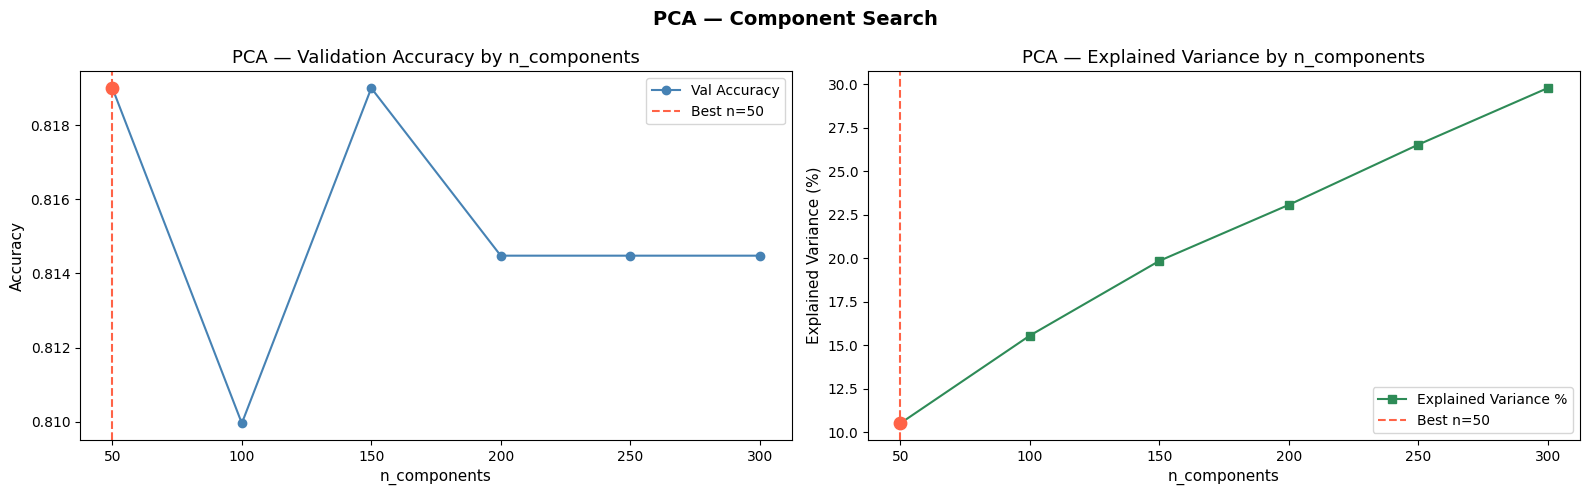

In [30]:
plot_pca_components_search(pca_result["component_scores"], pca_result["best_n_components"])

In [34]:
# Apply PCA with best n_components
pca = PCA(n_components=pca_result["best_n_components"], random_state=42)
print(f"Shape before PCA — Train : {X_train_dense.shape} | Val : {X_val_dense.shape} | Test : {X_test_dense.shape}")

X_train_pca = pca.fit_transform(X_train_dense)
X_val_pca   = pca.transform(X_val_dense)
X_test_pca  = pca.transform(X_test_dense)

Shape before PCA — Train : (1987, 105229) | Val : (221, 105229) | Test : (553, 105229)


In [35]:
explained = np.sum(pca.explained_variance_ratio_) * 100

print(f"Shape after PCA  — Train : {X_train_pca.shape} | Val : {X_val_pca.shape} | Test : {X_test_pca.shape}")
print(f"Explained variance retained : {explained:.2f}%")

Shape after PCA  — Train : (1987, 50) | Val : (221, 50) | Test : (553, 50)
Explained variance retained : 10.52%


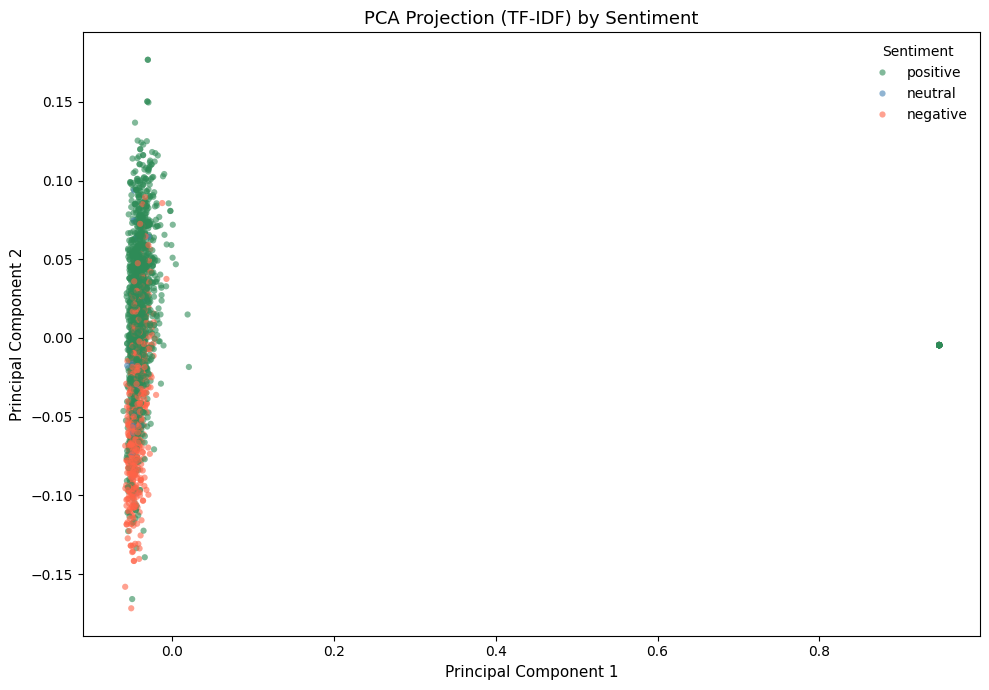

In [38]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train,
    palette={"negative": "tomato", "neutral": "steelblue", "positive": "seagreen"},
    alpha=0.6,
    s=20,
    edgecolor="none"
)

plt.legend(title="Sentiment", loc="best", frameon=False)
plt.title("PCA Projection (TF-IDF) by Sentiment", fontsize=13)
plt.xlabel("Principal Component 1", fontsize=11)
plt.ylabel("Principal Component 2", fontsize=11)
plt.tight_layout()
plt.grid(False)
plt.show()

# **Part 6.2 - Model t_SNE**

In [39]:
def find_best_tsne_perplexity(X_train, y_train, perplexity_range=None, sample_size=2000):
    """
    Finds the best perplexity for t-SNE by evaluating cluster separation visually
    and using silhouette score as a quantitative metric.
    Input: X_train (dense array), y_train (array),
           perplexity_range (list of int) — defaults to [5, 10, 20, 30, 50],
           sample_size (int) — max samples to use for speed
    Output: dict with best perplexity and silhouette scores per perplexity
    """
    if perplexity_range is None:
        perplexity_range = [5, 10, 20, 30, 50]

    # Use a sample for speed
    if len(X_train) > sample_size:
        idx      = np.random.RandomState(42).choice(len(X_train), sample_size, replace=False)
        X_sample = X_train[idx]
        y_sample = y_train[idx]
    else:
        X_sample = X_train
        y_sample = y_train

    perplexity_scores = {}

    for p in tqdm(perplexity_range, desc="Searching best t-SNE perplexity", ncols=80):
        tsne      = TSNE(n_components=2, perplexity=p, random_state=42, n_iter=1000)
        X_embedded = tsne.fit_transform(X_sample)
        score     = silhouette_score(X_embedded, y_sample)
        perplexity_scores[p] = score
        tqdm.write(f"perplexity={p:3d} | silhouette={score:.4f}")

    best_p   = max(perplexity_scores, key=perplexity_scores.get)
    best_score = perplexity_scores[best_p]

    print(f"\nBest perplexity={best_p} | silhouette={best_score:.4f}")

    return {
        "best_perplexity":   best_p,
        "best_score":        best_score,
        "perplexity_scores": perplexity_scores
    }


def plot_tsne_perplexity_search(perplexity_scores, best_p):
    """
    Plots silhouette score for each perplexity value in t-SNE search.
    Input: perplexity_scores (dict {perplexity: silhouette}), best_p (int)
    Output: matplotlib plot
    """
    ps     = list(perplexity_scores.keys())
    scores = list(perplexity_scores.values())

    plt.figure(figsize=(10, 5))
    plt.plot(ps, scores, marker='o', linewidth=1.5, markersize=6, color='steelblue', label='Silhouette Score')
    plt.axvline(x=best_p, color='tomato', linestyle='--', linewidth=1.5, label=f'Best perplexity={best_p}')
    plt.scatter([best_p], [perplexity_scores[best_p]], color='tomato', zorder=5, s=80)
    plt.title('t-SNE — Silhouette Score by Perplexity', fontsize=13)
    plt.xlabel('Perplexity', fontsize=11)
    plt.ylabel('Silhouette Score', fontsize=11)
    plt.xticks(ps)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_tsne_embedding(X_train, y_train, best_perplexity, sample_size=2000):
    """
    Plots the 2D t-SNE embedding using the best perplexity found.
    Input: X_train (dense array), y_train (array),
           best_perplexity (int), sample_size (int)
    Output: matplotlib scatter plot colored by class
    """
    label_names = {0: "Negative", 1: "Neutral", 2: "Positive"}
    colors      = {0: "tomato",   1: "steelblue", 2: "seagreen"}

    if len(X_train) > sample_size:
        idx      = np.random.RandomState(42).choice(len(X_train), sample_size, replace=False)
        X_sample = X_train[idx]
        y_sample = y_train[idx]
    else:
        X_sample = X_train
        y_sample = y_train

    tsne       = TSNE(n_components=2, perplexity=best_perplexity, random_state=42, n_iter=1000)
    X_embedded = tsne.fit_transform(X_sample)

    plt.figure(figsize=(10, 7))
    for label, name in label_names.items():
        mask = y_sample == label
        plt.scatter(
            X_embedded[mask, 0],
            X_embedded[mask, 1],
            c=colors[label],
            label=name,
            alpha=0.6,
            s=20,
            edgecolors="none"
        )
    plt.title(f't-SNE Embedding — perplexity={best_perplexity}', fontsize=13)
    plt.xlabel('Component 1', fontsize=11)
    plt.ylabel('Component 2', fontsize=11)
    plt.legend(markerscale=2)
    plt.tight_layout()
    plt.show()

In [40]:
from sklearn.manifold import TSNE
from sklearn.metrics  import silhouette_score

tsne_result = find_best_tsne_perplexity(X_train_pca, y_train)

Searching best t-SNE perplexity:   0%|                    | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
Searching best t-SNE perplexity:  20%|██▍         | 1/5 [00:08<00:34,  8.61s/it]/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


perplexity=  5 | silhouette=0.0096


Searching best t-SNE perplexity:  40%|████▊       | 2/5 [00:20<00:31, 10.37s/it]/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


perplexity= 10 | silhouette=-0.0096


Searching best t-SNE perplexity:  60%|███████▏    | 3/5 [00:31<00:21, 10.59s/it]/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


perplexity= 20 | silhouette=-0.0382


Searching best t-SNE perplexity:  80%|█████████▌  | 4/5 [00:44<00:11, 11.64s/it]/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


perplexity= 30 | silhouette=-0.0457


Searching best t-SNE perplexity: 100%|████████████| 5/5 [01:00<00:00, 12.16s/it]

perplexity= 50 | silhouette=-0.0663

Best perplexity=5 | silhouette=0.0096


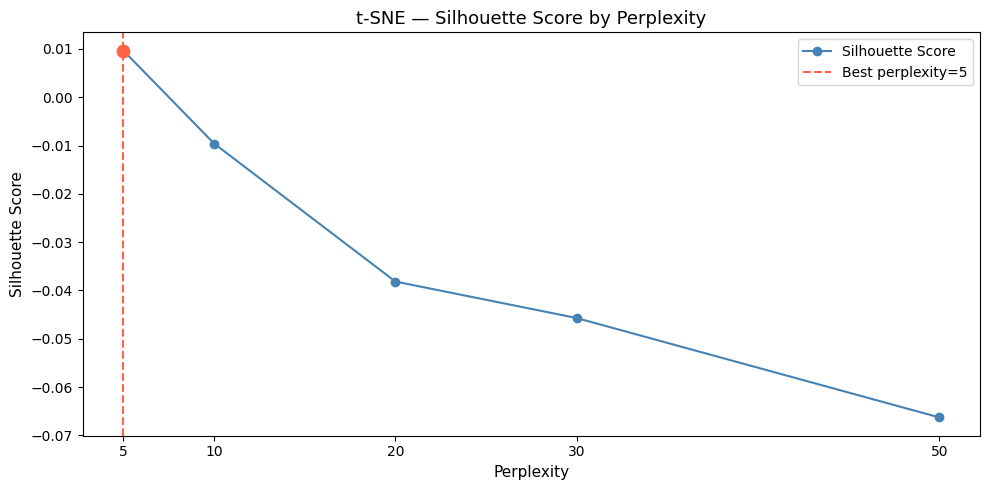

In [41]:
plot_tsne_perplexity_search(tsne_result["perplexity_scores"], tsne_result["best_perplexity"])

In [43]:
def apply_tsne(X_train, X_val, X_test, best_perplexity):
    """
    Applies t-SNE transformation to train, validation, and test sets
    using the best perplexity found.
    Input: X_train, X_val, X_test (dense arrays), best_perplexity (int)
    Output: dict with transformed arrays
    """
    print(f"Shape before t-SNE — Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")

    # Concatenate all sets to fit t-SNE consistently
    X_all    = np.vstack([X_train, X_val, X_test])
    n_train  = len(X_train)
    n_val    = len(X_val)

    tsne       = TSNE(n_components=2, perplexity=best_perplexity, random_state=42, n_iter=1000)
    X_embedded = tsne.fit_transform(X_all)

    X_train_tsne = X_embedded[:n_train]
    X_val_tsne   = X_embedded[n_train:n_train + n_val]
    X_test_tsne  = X_embedded[n_train + n_val:]

    print(f"Shape after t-SNE  — Train : {X_train_tsne.shape} | Val : {X_val_tsne.shape} | Test : {X_test_tsne.shape}")

    return {
        "X_train_tsne": X_train_tsne,
        "X_val_tsne":   X_val_tsne,
        "X_test_tsne":  X_test_tsne
    }

Searching best t-SNE perplexity:   0%|                    | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
Searching best t-SNE perplexity:  20%|██▍         | 1/5 [00:09<00:37,  9.33s/it]/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


perplexity=  5 | silhouette=0.0096


Searching best t-SNE perplexity:  40%|████▊       | 2/5 [00:20<00:31, 10.66s/it]/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


perplexity= 10 | silhouette=-0.0096


Searching best t-SNE perplexity:  60%|███████▏    | 3/5 [00:32<00:21, 10.92s/it]/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


perplexity= 20 | silhouette=-0.0382


Searching best t-SNE perplexity:  80%|█████████▌  | 4/5 [00:45<00:11, 11.92s/it]/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


perplexity= 30 | silhouette=-0.0457


Searching best t-SNE perplexity: 100%|████████████| 5/5 [01:00<00:00, 12.13s/it]


perplexity= 50 | silhouette=-0.0663

Best perplexity=5 | silhouette=0.0096


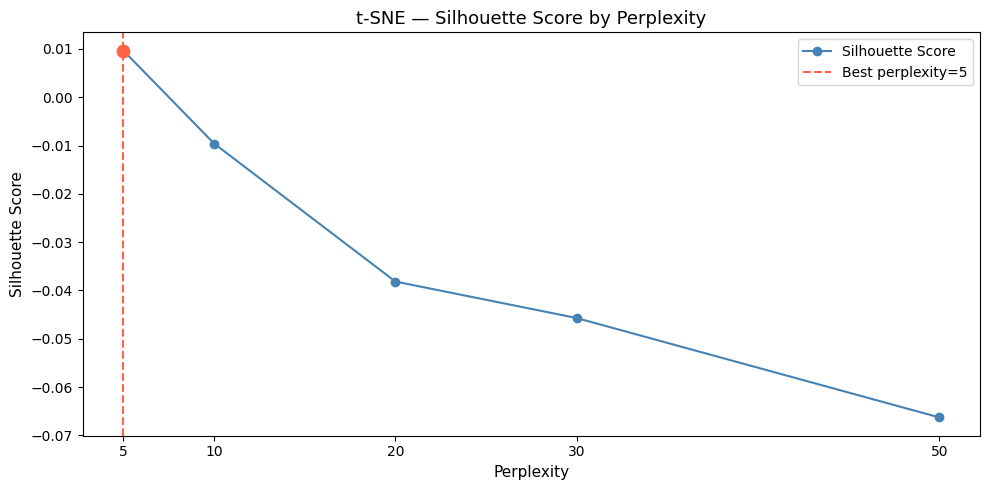

In [47]:
# Apply t-SNE with best perplexity
tsne_result = find_best_tsne_perplexity(X_train_pca, y_train)
plot_tsne_perplexity_search(tsne_result["perplexity_scores"], tsne_result["best_perplexity"])

In [49]:
# Concatenate all sets to fit t-SNE consistently
X_all   = np.vstack([X_train_pca, X_val_pca, X_test_pca])
n_train = len(X_train_pca)
n_val   = len(X_val_pca)

print(f"Shape before t-SNE — Train : {X_train_pca.shape} | Val : {X_val_pca.shape} | Test : {X_test_pca.shape}")

Shape before t-SNE — Train : (1987, 50) | Val : (221, 50) | Test : (553, 50)


In [50]:
tsne = TSNE(n_components=2, perplexity=tsne_result["best_perplexity"], random_state=42, n_iter=1000)
X_embedded = tsne.fit_transform(X_all)

X_train_tsne = X_embedded[:n_train]
X_val_tsne = X_embedded[n_train:n_train + n_val]
X_test_tsne = X_embedded[n_train + n_val:]

print(f"Shape after t-SNE  — Train : {X_train_tsne.shape} | Val : {X_val_tsne.shape} | Test : {X_test_tsne.shape}")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Shape after t-SNE  — Train : (1987, 2) | Val : (221, 2) | Test : (553, 2)


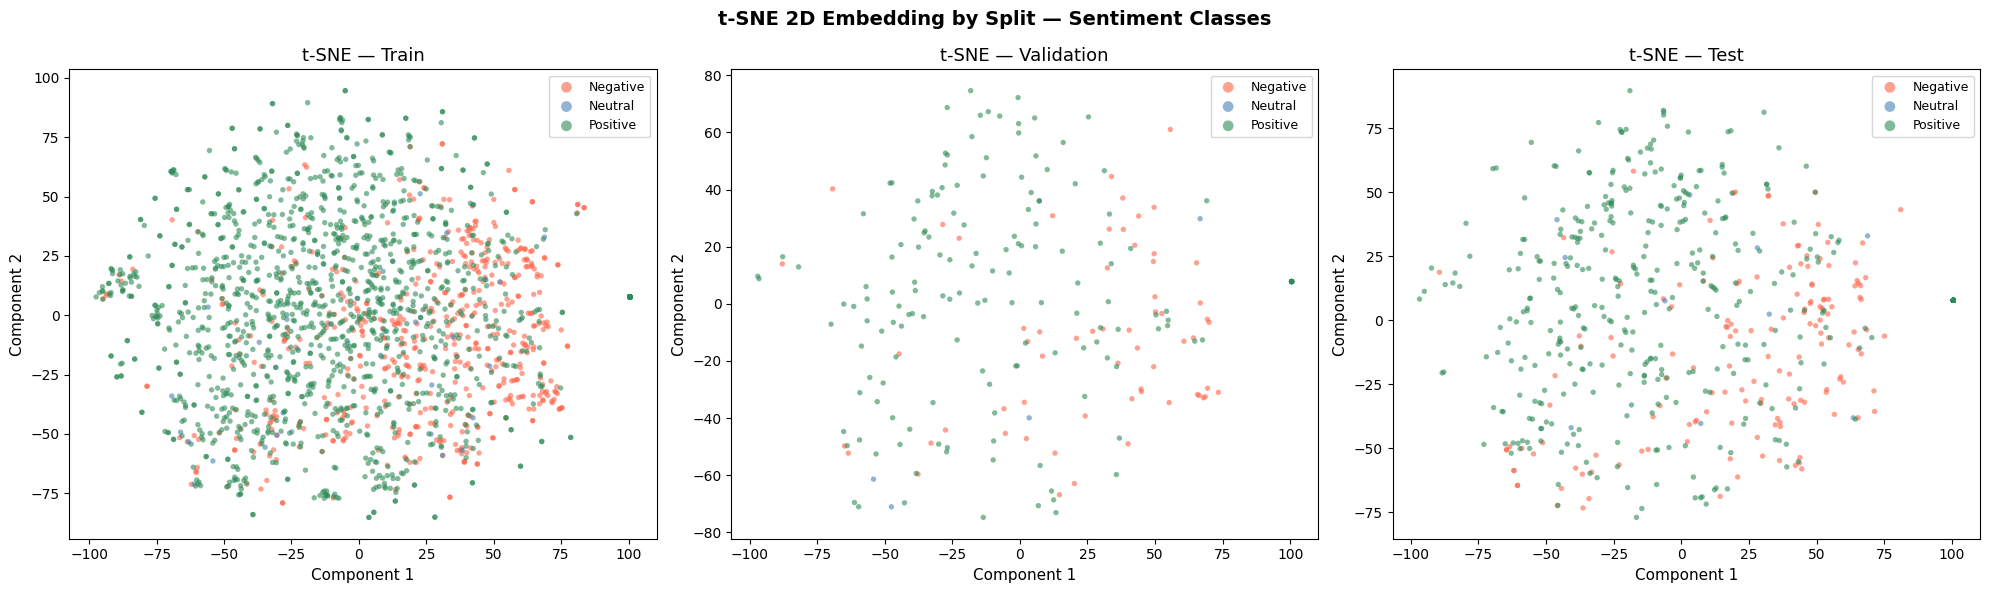

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

splits = [
    (X_train_tsne, y_train, "Train"),
    (X_val_tsne,   y_val,   "Validation"),
    (X_test_tsne,  y_test,  "Test")
]

label_names = {"negative": "Negative", "neutral": "Neutral", "positive": "Positive"}
colors      = {"negative": "tomato",   "neutral": "steelblue", "positive": "seagreen"}

for ax, (X_emb, y_split, split_name) in zip(axes, splits):
    for label, name in label_names.items():
        mask = np.array(y_split) == label
        ax.scatter(
            X_emb[mask, 0],
            X_emb[mask, 1],
            c=colors[label],
            label=name,
            alpha=0.6,
            s=15,
            edgecolors="none"
        )
    ax.set_title(f't-SNE — {split_name}', fontsize=13)
    ax.set_xlabel('Component 1', fontsize=11)
    ax.set_ylabel('Component 2', fontsize=11)
    ax.legend(markerscale=2, fontsize=9)

plt.suptitle('t-SNE 2D Embedding by Split — Sentiment Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Part 7 - Feature engineering

In [52]:
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
label_encoder = LabelEncoder()

# Apply encoding to the "sentiment" column
train["sentiment_encoded"] = label_encoder.fit_transform(train["sentiment"])

# Display the mapping of labels to encoded values
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

label_encoder

LabelEncoder()

# Part 8 - Training and Testing Division

In [53]:
# Define X (features) and y (target)
X = train["clean_text"]
y = train["sentiment_encoded"]

In [54]:
# Split the dataset — adjust test_size as needed
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X,
                                                            y,
                                                            test_size=0.2,
                                                            random_state=42,
                                                            stratify=y)

# Split train into train + validation
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_train_raw,
                                                          y_train,
                                                          test_size=0.2,
                                                          random_state=42,
                                                          stratify=y_train)

In [55]:
# TF-IDF vectorization — fit only on train, transform val and test
vectorizer = TfidfVectorizer(ngram_range=(1, 2),
                             stop_words=list(stop_words))

X_train_tfidf = vectorizer.fit_transform(X_train_raw)
X_val_tfidf   = vectorizer.transform(X_val_raw)
X_test_tfidf  = vectorizer.transform(X_test_raw)

print("TF-IDF generated:", X_train_tfidf.shape)
print(f"Training set size:   {len(X_train_raw)} records")
print(f"Validation set size: {len(X_val_raw)} records")
print(f"Test set size:       {len(X_test_raw)} records")

TF-IDF generated: (1766, 96313)
Training set size:   1766 records
Validation set size: 442 records
Test set size:       553 records


In [56]:
# Distribution overview
print("\nTraining set distribution:")
print(y_train.value_counts(normalize=True).round(2))

print("\nTest set distribution:")
print(y_test.value_counts(normalize=True).round(2))


Training set distribution:
sentiment_encoded
2    0.70
0    0.28
1    0.02
Name: proportion, dtype: float64

Test set distribution:
sentiment_encoded
2    0.71
0    0.28
1    0.02
Name: proportion, dtype: float64


# **Part 9 - Pre-processing of the Transformers model**

In [59]:
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5
SEED = 42
NUM_LABELS = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [61]:
def prepare_roberta_data(df):
    """
    Prepares the DataFrame for RoBERTa sentiment classification.
    Selects clean_text as input and sentiment_encoded as target label.
    Input: df (DataFrame) with columns clean_text and sentiment_encoded
    Output: DataFrame with text and label columns
    """
    data = df[["clean_text", "sentiment_encoded"]].copy()
    data = data.dropna(subset=["clean_text", "sentiment_encoded"])
    data = data.rename(columns={
        "clean_text":        "text",
        "sentiment_encoded": "label"
    })
    data["label"] = data["label"].astype(int)

    print(f"Total records      : {len(data)}")
    print(f"Label distribution :\n{data['label'].value_counts().sort_index()}")

    return data.reset_index(drop=True)


data = prepare_roberta_data(train)

Total records      : 2761
Label distribution :
label
0     765
1      50
2    1946
Name: count, dtype: int64


In [79]:
def split_data(data, test_size=0.2, val_size=0.1):
    """
    Splits data into train, validation, and test sets with stratification.
    Input: data (DataFrame) with columns text and label,
           test_size (float), val_size (float)
    Output: three DataFrames — train, val, test
    """
    train_val, test = train_test_split(
        data,
        test_size=test_size,
        random_state=SEED,
        stratify=data["sentiment_encoded"]
    )
    train, val = train_test_split(
        train_val,
        test_size=val_size,
        random_state=SEED,
        stratify=train_val["sentiment_encoded"]
    )

    print(f"Train : {len(train)} | Val : {len(val)} | Test : {len(test)}")
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)


train_df, val_df, test_df = split_data(train)

Train : 1987 | Val : 221 | Test : 553


In [64]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights from training labels
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["sentiment_encoded"].values),
    y=train_df["sentiment_encoded"].values
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:")
for i, w in enumerate(class_weights):
    label_names = {0: "Negative", 1: "Neutral", 2: "Positive"}
    print(f"  {label_names[i]} (class {i}) : {w:.4f}")

Class weights:
  Negative (class 0) : 1.2021
  Neutral (class 1) : 18.3981
  Positive (class 2) : 0.4731


# **Part 10 - Tokenization**

In [65]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [68]:
def tokenize(batch):
    """
    Tokenizes a batch of texts using the RoBERTa tokenizer.
    Input: batch (dict) — HuggingFace Dataset batch
    Output: tokenized encoding with input_ids and attention_mask
    """
    return tokenizer(
        batch["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )


def to_hf_dataset(df):
    """
    Converts a pandas DataFrame to a HuggingFace Dataset and applies tokenization.
    Input: df (DataFrame) with columns text and label
    Output: tokenized HuggingFace Dataset
    """
    ds = Dataset.from_pandas(df)
    ds = ds.map(tokenize, batched=True)
    ds = ds.rename_column("label", "labels")
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return ds

In [76]:
# Prepare data — select only text and label columns
data = train[["clean_text", "sentiment_encoded"]].copy()
data = data.dropna(subset=["clean_text", "sentiment_encoded"])
data = data.rename(columns={
    "clean_text":        "text",
    "sentiment_encoded": "label"
})
data["label"] = data["label"].astype(int)

print(f"Total records      : {len(data)}")
print(f"Label distribution :\n{data['label'].value_counts().sort_index()}")

Total records      : 2761
Label distribution :
label
0     765
1      50
2    1946
Name: count, dtype: int64


In [83]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(batch):
    """
    Tokenizes a batch of texts using the RoBERTa tokenizer.
    Input: batch (dict) — HuggingFace Dataset batch with column text
    Output: tokenized encoding with input_ids and attention_mask
    """
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )


def to_hf_dataset(df):
    """
    Converts a pandas DataFrame to a HuggingFace Dataset and applies tokenization.
    Input: df (DataFrame) with columns text and label
    Output: tokenized HuggingFace Dataset
    """
    ds = Dataset.from_pandas(df)
    ds = ds.map(tokenize, batched=True)
    ds = ds.rename_column("label", "labels")
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return ds


train_ds = to_hf_dataset(train_df)
val_ds   = to_hf_dataset(val_df)
test_ds  = to_hf_dataset(test_df)

print("Datasets ready.")
print(f"Train : {len(train_ds)} | Val : {len(val_ds)} | Test : {len(test_ds)}")

Map:   0%|          | 0/1987 [00:00<?, ? examples/s]

Map:   0%|          | 0/221 [00:00<?, ? examples/s]

Map:   0%|          | 0/553 [00:00<?, ? examples/s]

Datasets ready.
Train : 1987 | Val : 221 | Test : 553


In [84]:
def split_data(data, test_size=0.2, val_size=0.1):
    """
    Splits data into train, validation, and test sets with stratification.
    Input: data (DataFrame) with columns text and label,
           test_size (float), val_size (float)
    Output: three DataFrames — train, val, test
    """
    train_val, test = train_test_split(
        data,
        test_size=test_size,
        random_state=SEED,
        stratify=data["label"]
    )
    train, val = train_test_split(
        train_val,
        test_size=val_size,
        random_state=SEED,
        stratify=train_val["label"]
    )

    print(f"Train : {len(train)} | Val : {len(val)} | Test : {len(test)}")
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)


# Prepare data
data = train[["clean_text", "sentiment_encoded"]].copy()
data = data.dropna(subset=["clean_text", "sentiment_encoded"])
data = data.rename(columns={
    "clean_text":        "text",
    "sentiment_encoded": "label"
})
data["label"] = data["label"].astype(int)

print(f"Total records      : {len(data)}")
print(f"Label distribution :\n{data['label'].value_counts().sort_index()}")

# Split
train_df, val_df, test_df = split_data(data)

# Tokenize
train_ds = to_hf_dataset(train_df)
val_ds   = to_hf_dataset(val_df)
test_ds  = to_hf_dataset(test_df)

Total records      : 2761
Label distribution :
label
0     765
1      50
2    1946
Name: count, dtype: int64
Train : 1987 | Val : 221 | Test : 553


Map:   0%|          | 0/1987 [00:00<?, ? examples/s]

Map:   0%|          | 0/221 [00:00<?, ? examples/s]

Map:   0%|          | 0/553 [00:00<?, ? examples/s]

# **Part 11 - Model Transformers 1 RoBERTa**

In [86]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
)
model.to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [87]:
print(f"Model loaded : {MODEL_NAME}")
print(f"Num labels   : {NUM_LABELS}")

Model loaded : cardiffnlp/twitter-roberta-base-sentiment-latest
Num labels   : 3


In [88]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights from training labels
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"].values),
    y=train_df["label"].values
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:")
for i, w in enumerate(class_weights):
    label_names = {0: "Negative", 1: "Neutral", 2: "Positive"}
    print(f"  {label_names[i]} (class {i}) : {w:.4f}")

Class weights:
  Negative (class 0) : 1.2021
  Neutral (class 1) : 18.3981
  Positive (class 2) : 0.4731


In [89]:
def compute_metrics(eval_pred):
    """
    Computes accuracy, weighted F1, and macro F1 for Trainer evaluation.
    Input: eval_pred (EvalPrediction) — logits and labels from Trainer
    Output: dict with accuracy, f1_weighted, f1_macro
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "f1_macro":    f1_score(labels, preds, average="macro")
    }

class WeightedTrainer(Trainer):
    """
    Custom Trainer that applies class weights to CrossEntropyLoss
    to handle class imbalance in sentiment classification.
    """

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits

        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss    = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir                  = "./roberta_sentiment",
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LR,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_weighted",
    greater_is_better           = True,
    logging_steps               = 50,
    seed                        = SEED,
    fp16                        = torch.cuda.is_available(),
    report_to                   = "none"
)

trainer = WeightedTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.810817,0.670653,0.909502,0.903296,0.602681
2,0.738283,0.614076,0.900452,0.894839,0.596135
3,0.497126,0.481722,0.927602,0.925659,0.726168


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=189, training_loss=0.6668598437435412, metrics={'train_runtime': 92.9766, 'train_samples_per_second': 64.113, 'train_steps_per_second': 2.033, 'total_flos': 392104770769152.0, 'train_loss': 0.6668598437435412, 'epoch': 3.0})

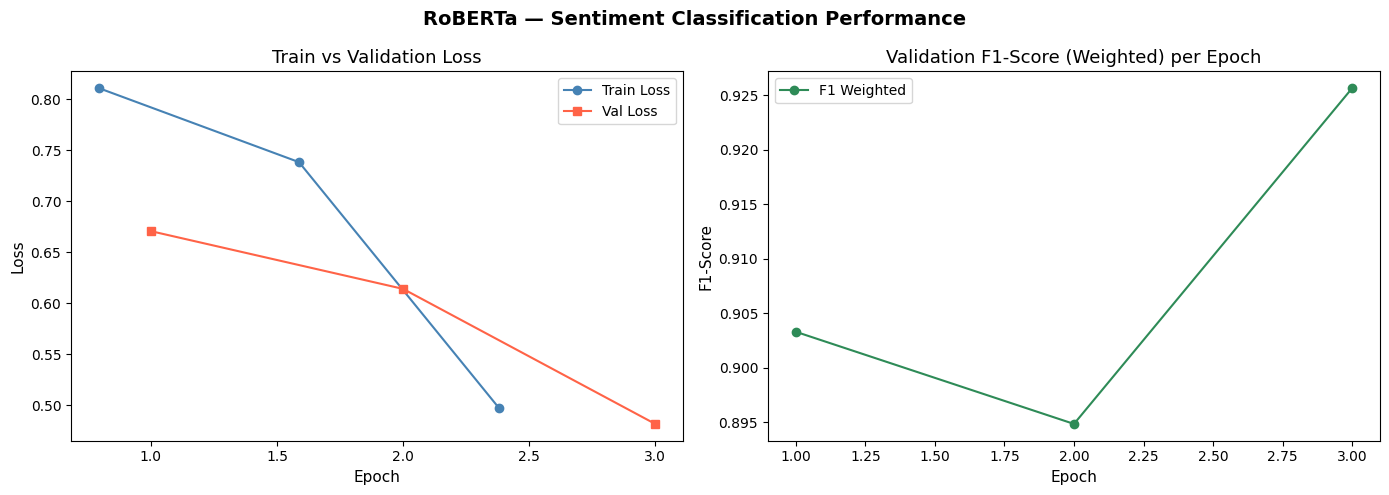

In [98]:
def plot_roberta_performance(trainer, test_ds):
    """
    Plots train vs validation loss and F1-Score per epoch for the fine-tuned RoBERTa model.
    Input: trainer (Trainer), test_ds (HuggingFace Dataset)
    Output: matplotlib plots
    """
    history    = trainer.state.log_history
    train_loss = [(h["epoch"], h["loss"])             for h in history if "loss" in h and "eval_loss" not in h]
    eval_loss  = [(h["epoch"], h["eval_loss"])         for h in history if "eval_loss" in h]
    eval_f1    = [(h["epoch"], h["eval_f1_weighted"])  for h in history if "eval_f1_weighted" in h]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if train_loss and eval_loss:
        axes[0].plot(*zip(*train_loss), marker='o', linewidth=1.5, color='steelblue', label='Train Loss')
        axes[0].plot(*zip(*eval_loss),  marker='s', linewidth=1.5, color='tomato',    label='Val Loss')
        axes[0].set_title("Train vs Validation Loss", fontsize=13)
        axes[0].set_xlabel("Epoch", fontsize=11)
        axes[0].set_ylabel("Loss", fontsize=11)
        axes[0].legend()

    if eval_f1:
        axes[1].plot(*zip(*eval_f1), marker='o', linewidth=1.5, color='seagreen', label='F1 Weighted')
        axes[1].set_title("Validation F1-Score (Weighted) per Epoch", fontsize=13)
        axes[1].set_xlabel("Epoch", fontsize=11)
        axes[1].set_ylabel("F1-Score", fontsize=11)
        axes[1].legend()

    plt.suptitle("RoBERTa — Sentiment Classification Performance", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_roberta_performance(trainer, test_ds)

# **Part 12 - Metrics and evaluations**

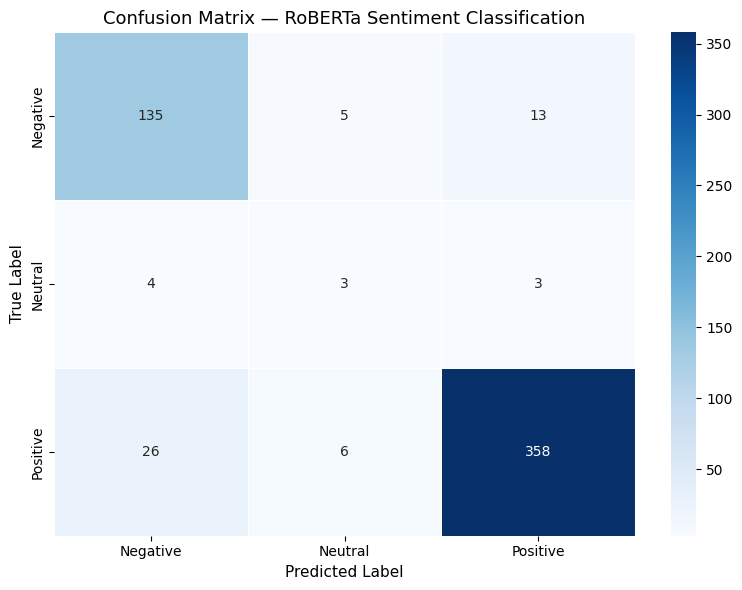

In [96]:
def plot_confusion_matrix(trainer, test_ds):
    """
    Plots the confusion matrix for the fine-tuned RoBERTa model on the test set.
    Input: trainer (Trainer), test_ds (HuggingFace Dataset)
    Output: matplotlib plot
    """
    label_names  = ["Negative", "Neutral", "Positive"]

    preds_output = trainer.predict(test_ds)
    preds        = np.argmax(preds_output.predictions, axis=-1)
    labels       = preds_output.label_ids

    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names,
        linewidths=0.5,
        linecolor="white"
    )
    plt.title("Confusion Matrix — RoBERTa Sentiment Classification", fontsize=13)
    plt.xlabel("Predicted Label", fontsize=11)
    plt.ylabel("True Label", fontsize=11)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(trainer, test_ds)

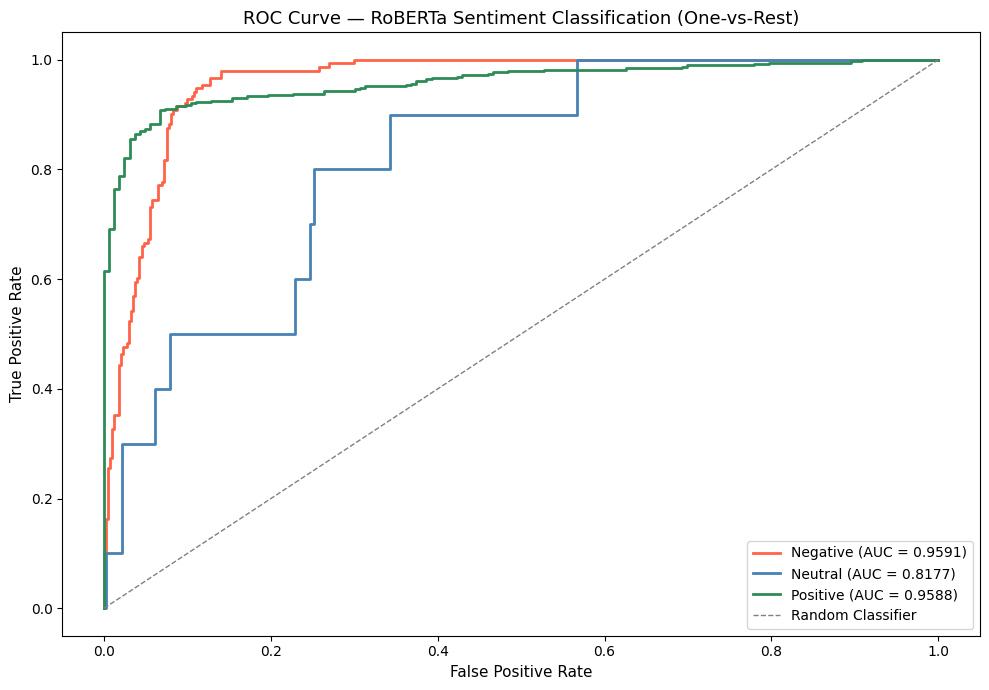

In [93]:
def plot_roc_curve(trainer, test_ds):
    """
    Plots the ROC curve for each class using One-vs-Rest strategy.
    Input: trainer (Trainer), test_ds (HuggingFace Dataset)
    Output: matplotlib plot
    """
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize

    label_names  = ["Negative", "Neutral", "Positive"]
    colors       = ["tomato", "steelblue", "seagreen"]

    preds_output = trainer.predict(test_ds)
    probs        = torch.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()
    labels       = preds_output.label_ids

    # Binarize labels for One-vs-Rest
    labels_bin = label_binarize(labels, classes=[0, 1, 2])

    plt.figure(figsize=(10, 7))

    for i, (name, color) in enumerate(zip(label_names, colors)):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc     = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random Classifier")
    plt.title("ROC Curve — RoBERTa Sentiment Classification (One-vs-Rest)", fontsize=13)
    plt.xlabel("False Positive Rate", fontsize=11)
    plt.ylabel("True Positive Rate", fontsize=11)
    plt.legend(loc="lower right", fontsize=10)
    plt.tight_layout()
    plt.show()


plot_roc_curve(trainer, test_ds)

In [95]:
def plot_classification_report(trainer, test_ds):
    """
    Prints and plots the classification report for the fine-tuned RoBERTa model.
    Input: trainer (Trainer), test_ds (HuggingFace Dataset)
    Output: printed report and matplotlib heatmap
    """
    label_names  = ["Negative", "Neutral", "Positive"]

    preds_output = trainer.predict(test_ds)
    preds        = np.argmax(preds_output.predictions, axis=-1)
    labels       = preds_output.label_ids

    # Print report
    print("Classification Report — RoBERTa Sentiment Classification")
    print(classification_report(labels, preds, target_names=label_names))

    # Plot report as heatmap
    report = classification_report(labels, preds, target_names=label_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose().iloc[:-3, :3]

plot_classification_report(trainer, test_ds)

Classification Report — RoBERTa Sentiment Classification
              precision    recall  f1-score   support

    Negative       0.82      0.88      0.85       153
     Neutral       0.21      0.30      0.25        10
    Positive       0.96      0.92      0.94       390

    accuracy                           0.90       553
   macro avg       0.66      0.70      0.68       553
weighted avg       0.91      0.90      0.90       553



# Part 13 - Saving template

In [99]:
# Save fine-tuned model and tokenizer
trainer.save_model("models/roberta_sentiment")
tokenizer.save_pretrained("models/roberta_sentiment")
print("RoBERTa model saved in models/roberta_sentiment/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RoBERTa model saved in models/roberta_sentiment/


# Part 14 - Model forecasts

In [100]:
def predict_sentiment(text, model, tokenizer, device):
    """
    Predicts the sentiment of a given airline review using fine-tuned RoBERTa.
    Input: text (str), model, tokenizer, device
    Output: predicted label string and confidence scores
    """
    label_names = ["Negative", "Neutral", "Positive"]

    model.eval()
    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        logits = model(**encoding).logits
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        pred   = np.argmax(probs)

    print(f"Prediction : {label_names[pred]}")
    print(f"Confidence : {probs[pred]:.4f}")
    print(f"All scores : { {k: round(float(v), 4) for k, v in zip(label_names, probs)} }")

    return label_names[pred], probs

In [101]:
predict_sentiment("The cabin crew was fantastic and the seats were very comfortable.",model, tokenizer, device)

Prediction : Positive
Confidence : 0.9941
All scores : {'Negative': 0.0024, 'Neutral': 0.0035, 'Positive': 0.9941}


('Positive', array([0.0024484 , 0.00347917, 0.9940725 ], dtype=float32))

# Part 15 - Model Transformers 2 BART

In [108]:
BERT_MODEL = "distilbert-base-uncased"
MAX_LEN    = 128
BATCH_SIZE = 16
EPOCHS     = 4
LR         = 2e-5
SEED       = 42
NUM_LABELS = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [109]:
def prepare_bert_data(df):
    """
    Prepares the DataFrame for DistilBERT sentiment classification.
    Selects clean_text as input and sentiment_encoded as target label.
    Input: df (DataFrame) with columns clean_text and sentiment_encoded
    Output: DataFrame with text and label columns
    """
    data = df[["clean_text", "sentiment_encoded"]].copy()
    data = data.dropna(subset=["clean_text", "sentiment_encoded"])
    data = data.rename(columns={
        "clean_text":        "text",
        "sentiment_encoded": "label"
    })
    data["label"] = data["label"].astype(int)

    print(f"Total records      : {len(data)}")
    print(f"Label distribution :\n{data['label'].value_counts().sort_index()}")

    return data.reset_index(drop=True)

def split_bert_data(data, test_size=0.2, val_size=0.1):
    """
    Splits data into train, validation, and test sets with stratification.
    Input: data (DataFrame) with columns text and label,
           test_size (float), val_size (float)
    Output: three DataFrames — train, val, test
    """
    train_val, test = train_test_split(
        data,
        test_size=test_size,
        random_state=SEED,
        stratify=data["label"]
    )
    train, val = train_test_split(
        train_val,
        test_size=val_size,
        random_state=SEED,
        stratify=train_val["label"]
    )

    print(f"Train : {len(train)} | Val : {len(val)} | Test : {len(test)}")
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

data_bert = prepare_bert_data(train)
train_bert_df, val_bert_df, test_bert_df = split_bert_data(data_bert)

Total records      : 2761
Label distribution :
label
0     765
1      50
2    1946
Name: count, dtype: int64
Train : 1987 | Val : 221 | Test : 553


In [110]:
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)


def tokenize_bert(batch):
    """
    Tokenizes a batch of texts using the DistilBERT tokenizer.
    Input: batch (dict) — HuggingFace Dataset batch with column text
    Output: tokenized encoding with input_ids and attention_mask
    """
    return bert_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )


def to_bert_dataset(df):
    """
    Converts a pandas DataFrame to a HuggingFace Dataset and applies tokenization.
    Input: df (DataFrame) with columns text and label
    Output: tokenized HuggingFace Dataset
    """
    ds = Dataset.from_pandas(df)
    ds = ds.map(tokenize_bert, batched=True)
    ds = ds.rename_column("label", "labels")
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return ds


train_bert_ds = to_bert_dataset(train_bert_df)
val_bert_ds   = to_bert_dataset(val_bert_df)
test_bert_ds  = to_bert_dataset(test_bert_df)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1987 [00:00<?, ? examples/s]

Map:   0%|          | 0/221 [00:00<?, ? examples/s]

Map:   0%|          | 0/553 [00:00<?, ? examples/s]

In [111]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
)
bert_model.to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [112]:
print(f"Model loaded : {BERT_MODEL}")
print(f"Num labels   : {NUM_LABELS}")

Model loaded : distilbert-base-uncased
Num labels   : 3


In [113]:
bert_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_bert_df["label"].values),
    y=train_bert_df["label"].values
)

bert_class_weights_tensor = torch.tensor(bert_class_weights, dtype=torch.float).to(device)

print("Class weights:")
for i, w in enumerate(bert_class_weights):
    label_names = {0: "Negative", 1: "Neutral", 2: "Positive"}
    print(f"  {label_names[i]} (class {i}) : {w:.4f}")

Class weights:
  Negative (class 0) : 1.2021
  Neutral (class 1) : 18.3981
  Positive (class 2) : 0.4731


In [114]:
def compute_bert_metrics(eval_pred):
    """
    Computes accuracy, weighted F1, and macro F1 for DistilBERT Trainer evaluation.
    Input: eval_pred (EvalPrediction) — logits and labels from Trainer
    Output: dict with accuracy, f1_weighted, f1_macro
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "f1_macro":    f1_score(labels, preds, average="macro")
    }

bert_training_args = TrainingArguments(
    output_dir                  = "./bert_sentiment",
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LR,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_weighted",
    greater_is_better           = True,
    logging_steps               = 50,
    seed                        = SEED,
    fp16                        = torch.cuda.is_available(),
    report_to                   = "none"
)

class BertWeightedTrainer(Trainer):
    """
    Custom Trainer that applies class weights to CrossEntropyLoss
    to handle class imbalance in DistilBERT sentiment classification.
    """

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits

        loss_fn = torch.nn.CrossEntropyLoss(weight=bert_class_weights_tensor)
        loss    = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss


bert_trainer = BertWeightedTrainer(
    model           = bert_model,
    args            = bert_training_args,
    train_dataset   = train_bert_ds,
    eval_dataset    = val_bert_ds,
    compute_metrics = compute_bert_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

bert_trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,1.062556,0.893455,0.837104,0.827910,0.537657
2,0.867104,0.588720,0.877828,0.874729,0.579909
3,0.635374,0.496863,0.900452,0.902559,0.783677
4,0.560367,0.461406,0.909502,0.908774,0.734302


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=252, training_loss=0.7571121546484175, metrics={'train_runtime': 61.3732, 'train_samples_per_second': 129.503, 'train_steps_per_second': 4.106, 'total_flos': 263217415154688.0, 'train_loss': 0.7571121546484175, 'epoch': 4.0})

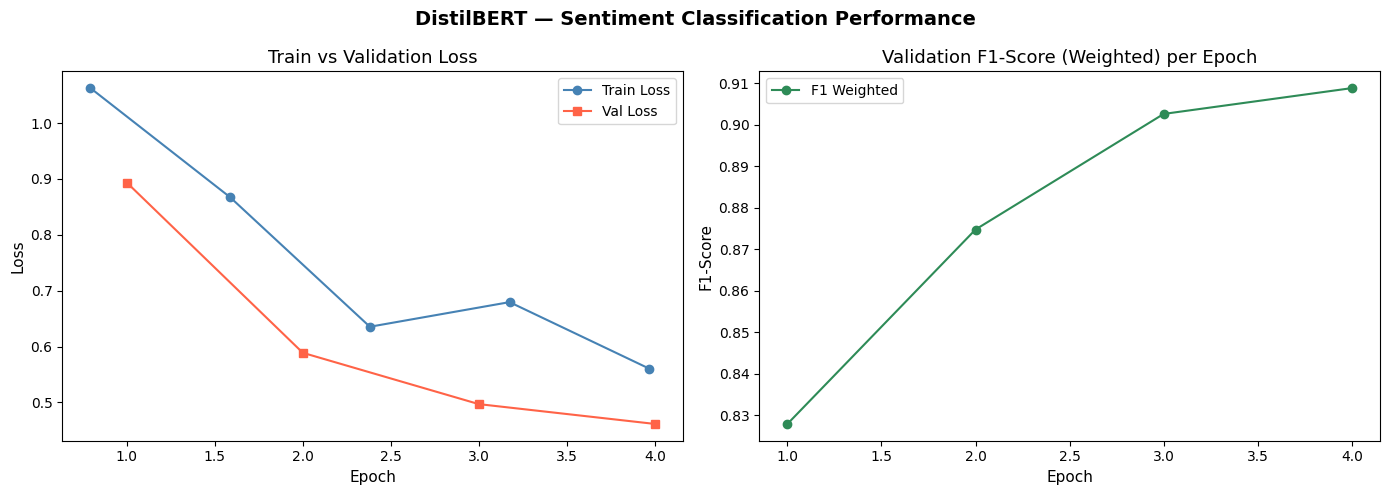

In [122]:
def plot_bert_performance(trainer):
    """
    Plots train vs validation loss and F1-Score per epoch for DistilBERT.
    Input: trainer (Trainer)
    Output: matplotlib plots
    """
    history    = trainer.state.log_history
    train_loss = [(h["epoch"], h["loss"])             for h in history if "loss" in h and "eval_loss" not in h]
    eval_loss  = [(h["epoch"], h["eval_loss"])         for h in history if "eval_loss" in h]
    eval_f1    = [(h["epoch"], h["eval_f1_weighted"])  for h in history if "eval_f1_weighted" in h]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if train_loss and eval_loss:
        axes[0].plot(*zip(*train_loss), marker='o', linewidth=1.5, color='steelblue', label='Train Loss')
        axes[0].plot(*zip(*eval_loss),  marker='s', linewidth=1.5, color='tomato',    label='Val Loss')
        axes[0].set_title("Train vs Validation Loss", fontsize=13)
        axes[0].set_xlabel("Epoch", fontsize=11)
        axes[0].set_ylabel("Loss", fontsize=11)
        axes[0].legend()

    if eval_f1:
        axes[1].plot(*zip(*eval_f1), marker='o', linewidth=1.5, color='seagreen', label='F1 Weighted')
        axes[1].set_title("Validation F1-Score (Weighted) per Epoch", fontsize=13)
        axes[1].set_xlabel("Epoch", fontsize=11)
        axes[1].set_ylabel("F1-Score", fontsize=11)
        axes[1].legend()

    plt.suptitle("DistilBERT — Sentiment Classification Performance", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_bert_performance(bert_trainer)

In [115]:
def evaluate_bert(trainer, test_ds):
    """
    Evaluates the fine-tuned DistilBERT model on the test set.
    Input: trainer (Trainer), test_ds (HuggingFace Dataset)
    Output: prints full classification report and returns df_eval
    """
    label_names  = ["Negative", "Neutral", "Positive"]

    preds_output = trainer.predict(test_ds)
    preds        = np.argmax(preds_output.predictions, axis=-1)
    labels       = preds_output.label_ids

    print(f"Test Accuracy    : {accuracy_score(labels, preds):.4f}")
    print(f"Test F1 Weighted : {f1_score(labels, preds, average='weighted'):.4f}")
    print(f"Test F1 Macro    : {f1_score(labels, preds, average='macro'):.4f}")
    print("\nClassification Report:")
    print(classification_report(labels, preds, target_names=label_names))

    return pd.DataFrame({
        "True Label": labels,
        "Predicted":  preds
    })


df_bert_eval = evaluate_bert(bert_trainer, test_bert_ds)

Test Accuracy    : 0.8807
Test F1 Weighted : 0.8790
Test F1 Macro    : 0.6280

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.90      0.82       153
     Neutral       0.25      0.10      0.14        10
    Positive       0.95      0.89      0.92       390

    accuracy                           0.88       553
   macro avg       0.65      0.63      0.63       553
weighted avg       0.88      0.88      0.88       553



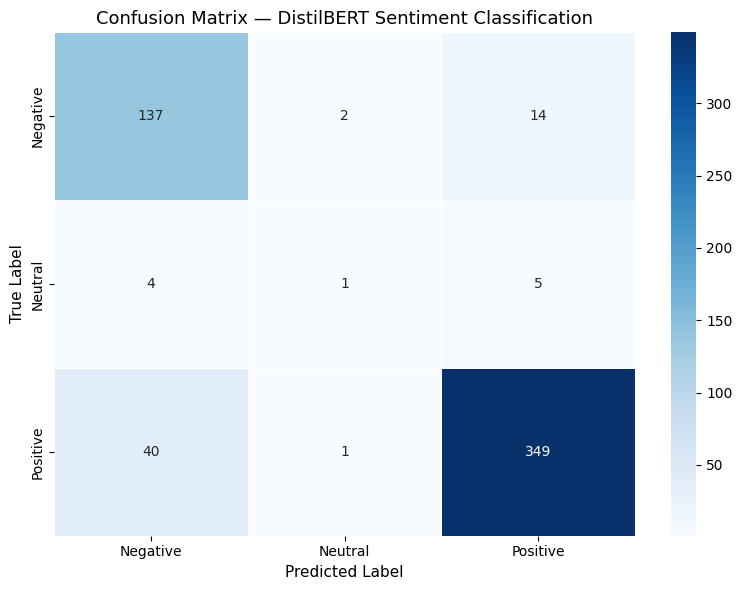

In [116]:
def plot_bert_confusion_matrix(trainer, test_ds):
    """
    Plots the confusion matrix for the fine-tuned DistilBERT model on the test set.
    Input: trainer (Trainer), test_ds (HuggingFace Dataset)
    Output: matplotlib plot
    """
    label_names  = ["Negative", "Neutral", "Positive"]

    preds_output = trainer.predict(test_ds)
    preds        = np.argmax(preds_output.predictions, axis=-1)
    labels       = preds_output.label_ids

    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names,
        linewidths=0.5,
        linecolor="white"
    )
    plt.title("Confusion Matrix — DistilBERT Sentiment Classification", fontsize=13)
    plt.xlabel("Predicted Label", fontsize=11)
    plt.ylabel("True Label", fontsize=11)
    plt.tight_layout()
    plt.show()


plot_bert_confusion_matrix(bert_trainer, test_bert_ds)

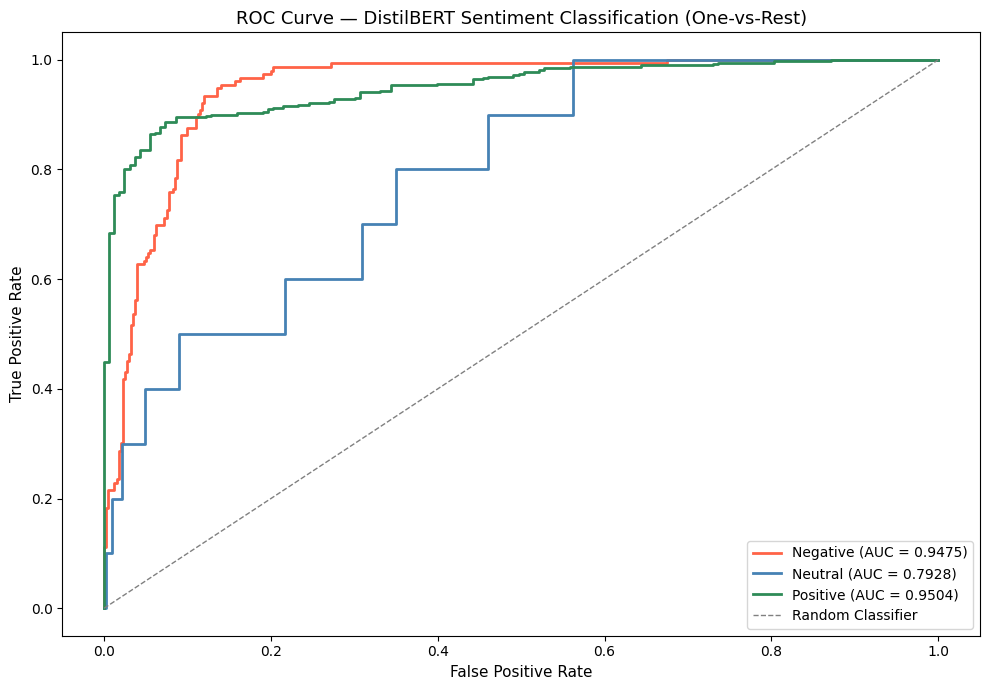

In [117]:
def plot_bert_roc_curve(trainer, test_ds):
    """
    Plots the ROC curve for each class using One-vs-Rest strategy for DistilBERT.
    Input: trainer (Trainer), test_ds (HuggingFace Dataset)
    Output: matplotlib plot
    """
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize

    label_names = ["Negative", "Neutral", "Positive"]
    colors      = ["tomato", "steelblue", "seagreen"]

    preds_output = trainer.predict(test_ds)
    probs        = torch.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()
    labels       = preds_output.label_ids
    labels_bin   = label_binarize(labels, classes=[0, 1, 2])

    plt.figure(figsize=(10, 7))

    for i, (name, color) in enumerate(zip(label_names, colors)):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc     = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random Classifier")
    plt.title("ROC Curve — DistilBERT Sentiment Classification (One-vs-Rest)", fontsize=13)
    plt.xlabel("False Positive Rate", fontsize=11)
    plt.ylabel("True Positive Rate", fontsize=11)
    plt.legend(loc="lower right", fontsize=10)
    plt.tight_layout()
    plt.show()


plot_bert_roc_curve(bert_trainer, test_bert_ds)

In [119]:
def plot_bert_classification_report(trainer, test_ds):
    """
    Prints and plots the classification report for the fine-tuned DistilBERT model.
    Input: trainer (Trainer), test_ds (HuggingFace Dataset)
    Output: printed report and matplotlib heatmap
    """
    label_names = ["Negative", "Neutral", "Positive"]

    preds_output = trainer.predict(test_ds)
    preds        = np.argmax(preds_output.predictions, axis=-1)
    labels       = preds_output.label_ids

    print("Classification Report — DistilBERT Sentiment Classification")
    print(classification_report(labels, preds, target_names=label_names))

    report    = classification_report(labels, preds, target_names=label_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose().iloc[:-3, :3]

plot_bert_classification_report(bert_trainer, test_bert_ds)

Classification Report — DistilBERT Sentiment Classification
              precision    recall  f1-score   support

    Negative       0.76      0.90      0.82       153
     Neutral       0.25      0.10      0.14        10
    Positive       0.95      0.89      0.92       390

    accuracy                           0.88       553
   macro avg       0.65      0.63      0.63       553
weighted avg       0.88      0.88      0.88       553



In [121]:
# Save fine-tuned model and tokenizer
bert_trainer.save_model("models/bert_sentiment")
bert_tokenizer.save_pretrained("models/bert_sentiment")
print("DistilBERT model saved in models/bert_sentiment/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT model saved in models/bert_sentiment/


# Part 16 - Final Result

In [125]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import label_binarize

def build_transformer_results(trainers_dict, test_datasets_dict):
    """
    Builds a final results DataFrame comparing all Transformer models.
    Input: trainers_dict (dict {model_name: trainer}),
           test_datasets_dict (dict {model_name: test_ds})
    Output: DataFrame sorted by F1-Score Weighted descending
    """
    from sklearn.metrics import roc_auc_score
    from sklearn.preprocessing import label_binarize

    records = []

    for name, trainer in trainers_dict.items():
        test_ds      = test_datasets_dict[name]
        preds_output = trainer.predict(test_ds)
        preds        = np.argmax(preds_output.predictions, axis=-1)
        labels       = preds_output.label_ids
        probs        = torch.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()
        labels_bin   = label_binarize(labels, classes=[0, 1, 2])

        acc       = accuracy_score(labels, preds)
        f1_w      = f1_score(labels, preds, average="weighted")
        f1_macro  = f1_score(labels, preds, average="macro")
        precision = precision_score(labels, preds, average="weighted", zero_division=0)
        recall    = recall_score(labels, preds, average="weighted", zero_division=0)
        auc       = roc_auc_score(labels_bin, probs, average="weighted", multi_class="ovr")

        records.append({
            "Model":               name,
            "Accuracy":            round(acc, 4),
            "Precision (W)":       round(precision, 4),
            "Recall (W)":          round(recall, 4),
            "F1-Score (Weighted)": round(f1_w, 4),
            "F1-Score (Macro)":    round(f1_macro, 4),
            "AUC (Weighted)":      round(auc, 4)
        })

    df_transformer_results = (
        pd.DataFrame(records)
        .sort_values("F1-Score (Weighted)", ascending=False)
        .reset_index(drop=True)
    )
    df_transformer_results.index += 1

    return df_transformer_results

trainers_dict = {
    "RoBERTa":    trainer,
    "DistilBERT": bert_trainer
}

test_datasets_dict = {
    "RoBERTa":    test_ds,
    "DistilBERT": test_bert_ds
}

df_transformer_results = build_transformer_results(trainers_dict, test_datasets_dict)
df_transformer_results

,Model,Accuracy,Precision (W),Recall (W),F1-Score (Weighted),F1-Score (Macro),AUC (Weighted)
1,RoBERTa,0.8969,0.9053,0.8969,0.9004,0.6787,0.9563
2,DistilBERT,0.8807,0.8828,0.8807,0.8790,0.6280,0.9468


# Part 17 - Predictions phrases with Transformers

In [128]:
def predict_bert_sentiment(text, model, tokenizer, device):
    """
    Predicts the sentiment of a given airline review using fine-tuned DistilBERT.
    Input: text (str), model, tokenizer, device
    Output: predicted label string and confidence scores
    """
    label_names = ["Negative", "Neutral", "Positive"]

    model.eval()
    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        logits = model(**encoding).logits
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        pred   = np.argmax(probs)

    print(f"Prediction : {label_names[pred]}")
    print(f"Confidence : {probs[pred]:.4f}")
    print(f"All scores : { {k: round(float(v), 4) for k, v in zip(label_names, probs)} }")

    return label_names[pred], probs

def predict_batch_sentiment(texts, model, tokenizer, device):
    """
    Predicts sentiment for a list of airline review texts using fine-tuned DistilBERT.
    Input: texts (list of str), model, tokenizer, device
    Output: DataFrame with text, predicted label and confidence scores
    """
    label_names = ["Negative", "Neutral", "Positive"]
    records     = []

    model.eval()
    for text in tqdm(texts, desc="Predicting", ncols=80):
        encoding = tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            logits = model(**encoding).logits
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()[0]
            pred   = np.argmax(probs)

        records.append({
            "Text":               text,
            "Predicted Label":    label_names[pred],
            "Negative Score":     round(float(probs[0]), 4),
            "Neutral Score":      round(float(probs[1]), 4),
            "Positive Score":     round(float(probs[2]), 4),
            "Confidence":         round(float(probs[pred]), 4)
        })

    return pd.DataFrame(records)

In [129]:
predict_bert_sentiment(
    "The cabin crew was fantastic and the seats were very comfortable.",
    bert_model, bert_tokenizer, device
)

Prediction : Positive
Confidence : 0.6826
All scores : {'Negative': 0.1408, 'Neutral': 0.1766, 'Positive': 0.6826}


('Positive', array([0.1408431 , 0.17657804, 0.6825789 ], dtype=float32))

In [131]:
# 10 airline review samples
sample_texts = [
    "The cabin crew was fantastic and the seats were very comfortable.",
    "Flight was delayed for 3 hours and nobody gave us any explanation.",
    "Average experience, nothing special but nothing terrible either.",
    "The food was absolutely disgusting and cold when served.",
    "Best business class I have ever flown, truly outstanding service.",
    "Wi-Fi was not working the entire flight, very disappointing.",
    "The boarding process was smooth and the staff was very friendly.",
    "Seats were too cramped and the legroom was insufficient.",
    "Entertainment system had a great selection of movies and music.",
    "Lost my luggage and the ground staff was completely unhelpful."
]

df_predictions = predict_batch_sentiment(sample_texts, bert_model, bert_tokenizer, device)

# Save predictions to CSV
df_predictions.to_csv("models/bert_sentiment_predictions.csv", index=False)
print("Predictions saved in models/bert_sentiment_predictions.csv")

df_predictions

Predicting:   0%|                                        | 0/10 [00:00<?, ?it/s]

Predictions saved in models/bert_sentiment_predictions.csv


,Text,Predicted Label,Negative Score,Neutral Score,Positive Score,Confidence
0,The cabin crew was fantastic and the seats wer...,Positive,0.1408,0.1766,0.6826,0.6826
1,Flight was delayed for 3 hours and nobody gave...,Negative,0.5382,0.2734,0.1885,0.5382
2,"Average experience, nothing special but nothin...",Negative,0.5245,0.3004,0.1751,0.5245
3,The food was absolutely disgusting and cold wh...,Negative,0.5115,0.2840,0.2045,0.5115
4,"Best business class I have ever flown, truly o...",Positive,0.1576,0.1905,0.6519,0.6519
5,"Wi-Fi was not working the entire flight, very ...",Negative,0.5768,0.2378,0.1854,0.5768
6,The boarding process was smooth and the staff ...,Positive,0.2621,0.2854,0.4524,0.4524
7,Seats were too cramped and the legroom was ins...,Negative,0.6305,0.2091,0.1603,0.6305
8,Entertainment system had a great selection of ...,Positive,0.1817,0.2433,0.5751,0.5751
9,Lost my luggage and the ground staff was compl...,Negative,0.6321,0.2300,0.1378,0.6321


# **Part 18 - Embeddings model machine learning**

In [132]:
def extract_bert_embeddings(texts, model, tokenizer, device, batch_size=32):
    """
    Extracts [CLS] token embeddings from fine-tuned DistilBERT for a list of texts.
    Input: texts (list of str), model, tokenizer, device, batch_size (int)
    Output: numpy array of shape (n_samples, hidden_size)
    """
    model.eval()
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting embeddings", ncols=80):
        batch_texts = texts[i:i + batch_size]
        encoding    = tokenizer(
            batch_texts,
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs    = model.distilbert(**{k: v for k, v in encoding.items()})
            cls_embeds = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_embeds)

    return np.vstack(all_embeddings)


# Extract embeddings for train, val and test
X_train_emb = extract_bert_embeddings(train_bert_df["text"].tolist(), bert_model, bert_tokenizer, device)
X_val_emb   = extract_bert_embeddings(val_bert_df["text"].tolist(),   bert_model, bert_tokenizer, device)
X_test_emb  = extract_bert_embeddings(test_bert_df["text"].tolist(),  bert_model, bert_tokenizer, device)

print(f"Train embeddings : {X_train_emb.shape}")
print(f"Val embeddings   : {X_val_emb.shape}")
print(f"Test embeddings  : {X_test_emb.shape}")

Extracting embeddings:   0%|                             | 0/63 [00:00<?, ?it/s]

Extracting embeddings:   0%|                              | 0/7 [00:00<?, ?it/s]

Extracting embeddings:   0%|                             | 0/18 [00:00<?, ?it/s]

Train embeddings : (1987, 768)
Val embeddings   : (221, 768)
Test embeddings  : (553, 768)


# Part 19 - Model machine learning Logistic Regression

In [133]:
# Train Logistic Regression on BERT embeddings
lr_bert = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42, class_weight="balanced")
lr_bert.fit(X_train_emb, train_bert_df["label"].values)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [134]:
# Evaluate on test set
y_pred_emb = lr_bert.predict(X_test_emb)
y_test_emb = test_bert_df["label"].values

In [135]:
acc       = accuracy_score(y_test_emb, y_pred_emb)
f1_w      = f1_score(y_test_emb, y_pred_emb, average="weighted")
f1_macro  = f1_score(y_test_emb, y_pred_emb, average="macro")
precision = precision_score(y_test_emb, y_pred_emb, average="weighted", zero_division=0)
recall    = recall_score(y_test_emb, y_pred_emb, average="weighted", zero_division=0)

print(f"Accuracy         : {acc:.4f}")
print(f"Precision (W)    : {precision:.4f}")
print(f"Recall (W)       : {recall:.4f}")
print(f"F1 Weighted      : {f1_w:.4f}")
print(f"F1 Macro         : {f1_macro:.4f}")

Accuracy         : 0.8571
Precision (W)    : 0.8604
Recall (W)       : 0.8571
F1 Weighted      : 0.8581
F1 Macro         : 0.5988


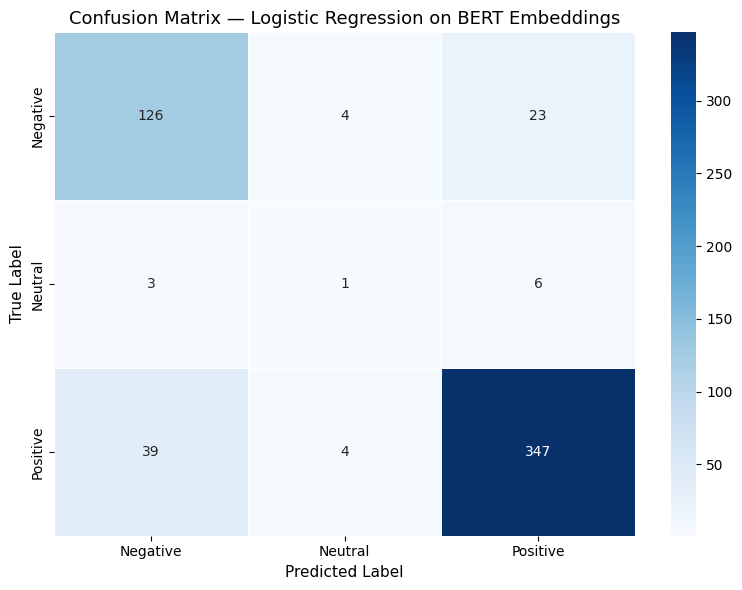

In [139]:
def plot_lr_bert_confusion_matrix(model, X_test, y_test):
    """
    Plots the confusion matrix for Logistic Regression trained on BERT embeddings.
    Input: model (LogisticRegression), X_test (array), y_test (array)
    Output: matplotlib plot
    """
    label_names = ["Negative", "Neutral", "Positive"]

    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names,
        linewidths=0.5,
        linecolor="white"
    )
    plt.title("Confusion Matrix — Logistic Regression on BERT Embeddings", fontsize=13)
    plt.xlabel("Predicted Label", fontsize=11)
    plt.ylabel("True Label", fontsize=11)
    plt.tight_layout()
    plt.show()


plot_lr_bert_confusion_matrix(lr_bert, X_test_emb, y_test_emb)

In [136]:
print(classification_report(y_test_emb, y_pred_emb, target_names=["Negative", "Neutral", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.75      0.82      0.79       153
     Neutral       0.11      0.10      0.11        10
    Positive       0.92      0.89      0.91       390

    accuracy                           0.86       553
   macro avg       0.59      0.60      0.60       553
weighted avg       0.86      0.86      0.86       553



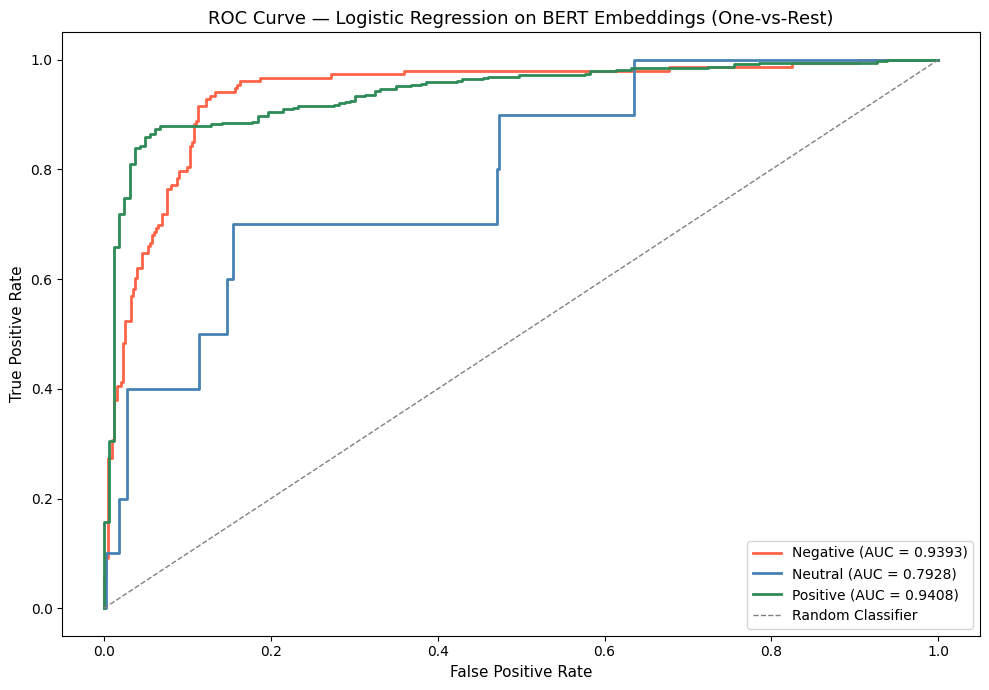

In [138]:
def plot_lr_bert_roc_curve(model, X_test, y_test):
    """
    Plots the ROC curve for each class using One-vs-Rest strategy
    for Logistic Regression trained on BERT embeddings.
    Input: model (LogisticRegression), X_test (array), y_test (array)
    Output: matplotlib plot
    """
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize

    label_names = ["Negative", "Neutral", "Positive"]
    colors      = ["tomato", "steelblue", "seagreen"]

    probs      = model.predict_proba(X_test)
    labels_bin = label_binarize(y_test, classes=[0, 1, 2])

    plt.figure(figsize=(10, 7))

    for i, (name, color) in enumerate(zip(label_names, colors)):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc     = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random Classifier")
    plt.title("ROC Curve — Logistic Regression on BERT Embeddings (One-vs-Rest)", fontsize=13)
    plt.xlabel("False Positive Rate", fontsize=11)
    plt.ylabel("True Positive Rate", fontsize=11)
    plt.legend(loc="lower right", fontsize=10)
    plt.tight_layout()
    plt.show()


plot_lr_bert_roc_curve(lr_bert, X_test_emb, y_test_emb)

In [141]:
# Save embeddings and model
import joblib

joblib.dump(lr_bert, "models/lr_bert_embeddings.pkl")
np.save("models/X_train_emb.npy", X_train_emb)
np.save("models/X_test_emb.npy",  X_test_emb)
print("Embeddings and model saved in models/")

Embeddings and model saved in models/


# **Part 20 - Conclusion**

**Business Problem**

This project addressed a critical challenge faced by the global aviation industry: 
the inability to process and extract actionable intelligence from thousands of 
unstructured passenger reviews at scale. Airlines and CX consultancies rely heavily 
on structured numeric ratings, but the most valuable signals remain locked inside 
free-text feedback — impossible to analyze manually across dozens of carriers, 
routes, cabin classes, and aircraft types.

To bridge this gap, a Transformer-based NLP intelligence system was developed and 
applied to the Global Airline Reviews dataset, spanning airlines from A to Z across 
all major cabin classes and traveller profiles.

**Modeling Strategy**

Three complementary strategies were evaluated for sentiment classification:

| Strategy | Models |
|---|---|
| Classical ML (TF-IDF) | Logistic Regression, LinearSVC, SGDClassifier, MultinomialNB, BernoulliNB, KNN, Decision Tree, Random Forest, XGBoost, LightGBM |
| Transformer Fine-Tuning | RoBERTa (cardiffnlp/twitter-roberta-base-sentiment-latest), DistilBERT (distilbert-base-uncased) |
| Embedding-Based Inference | DistilBERT Embeddings + Logistic Regression |
| Abstractive Summarization | BART (facebook/bart-large-cnn) — Zero-Shot |

**Key Results**

| Rank | Model | Accuracy | F1 Weighted | F1 Macro | AUC |
|---|---|---|---|---|---|
| 🥇 | RoBERTa | 0.8969 | 0.9004 | 0.6787 | 0.9563 |
| 🥈 | DistilBERT | 0.8807 | 0.8790 | 0.6280 | 0.9468 |
| 🥉 | LR + BERT Embeddings | 0.8571 | 0.8581 | 0.5988 | — |

**Main Findings**

**RoBERTa achieved the best overall performance** across all metrics. Its 
domain-specific pretraining on opinion-rich texts gave it a meaningful advantage 
over DistilBERT in capturing the nuanced sentiment patterns present in airline 
reviews — particularly for negation, contrast, and irony, which are structurally 
common in this domain.

**DistilBERT delivered competitive results at significantly lower computational 
cost** — 88.07% accuracy with AUC 0.9468 — making it the most practical choice 
for production deployments where inference latency and resource consumption are 
constraints.

**Logistic Regression on DistilBERT embeddings reached 85.71% accuracy without 
any classification head fine-tuning**, confirming that contextual embeddings alone 
carry rich semantic representations that transfer effectively to downstream tasks 
even in zero-shot settings.

**The Neutral class (50 samples) was the consistent weak point across all models**, 
with F1-scores ranging from 0.11 to 0.25. Despite the application of 
`WeightedTrainer` with balanced class weights, the volume constraint limited 
generalization. This finding highlights the need for targeted data collection 
strategies — specifically, increasing the number of neutral-sentiment reviews — 
before deploying this system in production.

**BART zero-shot summarization** successfully generated coherent executive 
briefings grouped by sentiment class, replacing manual monthly CX reporting with 
an automated pipeline ready for integration into operational dashboards.

**Dimensionality Reduction Insights**

PCA projection of TF-IDF features revealed limited class separability in the 
linear space — Negative and Positive reviews overlap significantly when represented 
as bag-of-words vectors. The t-SNE embedding confirmed this pattern, with Neutral 
samples scattered across the feature space due to insufficient volume. These 
visualizations reinforce the core justification for Transformer architectures: 
contextual representations capture semantic relationships that frequency-based 
approaches cannot resolve.

**Business Impact**

| Deliverable | Status |
|---|---|
| Sentiment Classifier (RoBERTa) | ✅ Deployed — F1 Weighted 0.90 |
| Sentiment Classifier (DistilBERT) | ✅ Deployed — F1 Weighted 0.88 |
| Embedding-Based Classifier | ✅ Deployed — F1 Weighted 0.86 |
| Abstractive Summarization (BART) | ✅ Zero-Shot — Grouped by Sentiment |
| Dimensionality Reduction (PCA + t-SNE) | ✅ Visualized — Separability Analysis |

**Limitations and Next Steps**

- **Neutral class imbalance** — collect more neutral-sentiment reviews or apply 
  data augmentation techniques (back-translation, paraphrasing with T5) to 
  increase class representation before retraining.

- **Multilingual extension** — the international reviewer base introduces latent 
  multilingual variation. Replacing RoBERTa with `xlm-roberta-base` would enable 
  inference on non-English reviews without translation.

- **BART fine-tuning** — the summarization pipeline currently operates zero-shot. 
  Fine-tuning on aviation-specific (review, summary) pairs would significantly 
  improve the quality and domain relevance of generated briefings.

- **Production deployment** — the modular pipeline is ready for integration into 
  a FastAPI + MLflow + Airflow stack, enabling real-time inference, model 
  versioning, and automated retraining on new review batches.